send finns: True
rec finns : True


C:\Users\lundi\AppData\Local\Temp\ipykernel_156292\1696457312.py:68: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_156292\1696457312.py:68: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")


Antal synkade tidssteg: 7669
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.450000

SAMMANFATTNING:


,Phase,U_send_mean,U_rec_mean,I_send_mean,I_rec_mean,U_ang_send_mean_deg,U_ang_rec_mean_deg,I_ang_send_mean_deg,I_ang_rec_raw_mean_deg,I_ang_rec_corr_mean_deg,dU_mean_deg,dI_mean_deg,P_send_mean_W,P_rec_mean_W
0,L1,80883.253383,80496.368343,191.352329,189.581683,164.599535,163.688732,162.736856,-18.258586,161.741414,0.898770,0.984417,1.546604e+07,1.524867e+07
1,L2,80873.212155,80555.784209,201.844450,199.935422,44.619834,43.732696,40.568157,-140.393725,39.606275,0.875989,0.954564,1.627749e+07,1.605842e+07
2,L3,80929.100680,80685.289530,192.831843,190.632206,-75.398451,-76.308712,-81.443610,97.118344,-82.881656,0.898759,1.459783,1.551126e+07,1.527066e+07


Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\overview_currents_voltages_angles_power


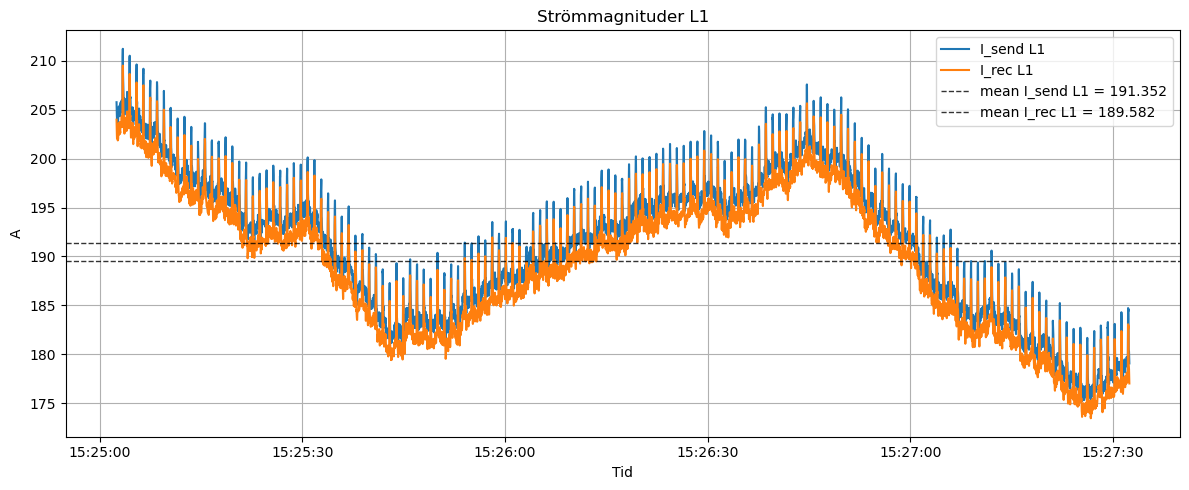

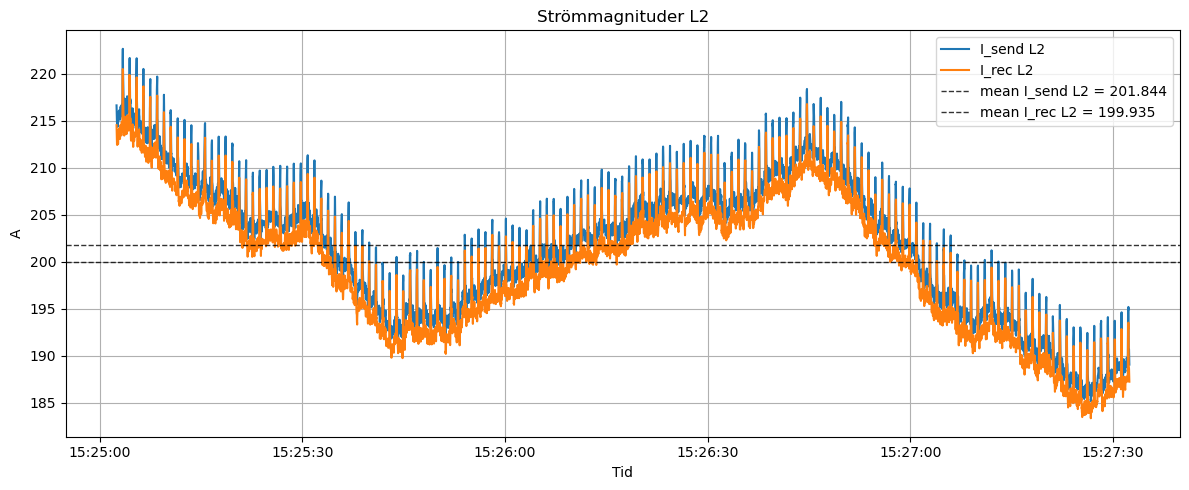

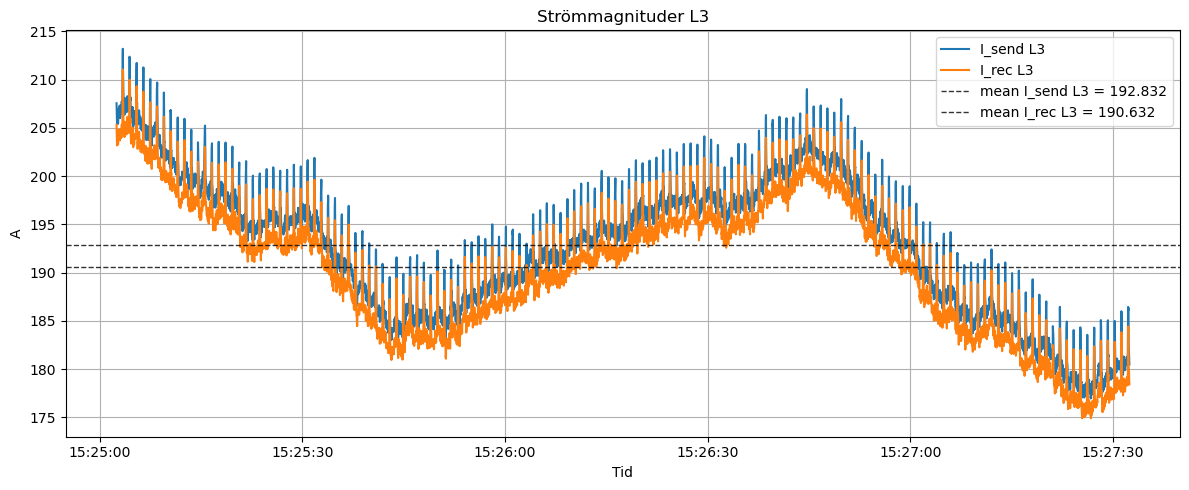

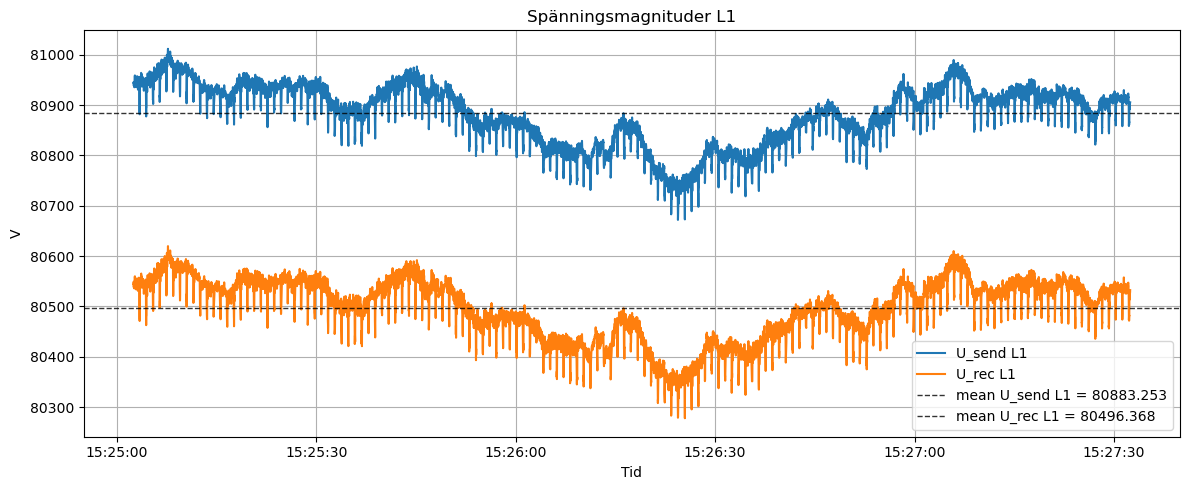

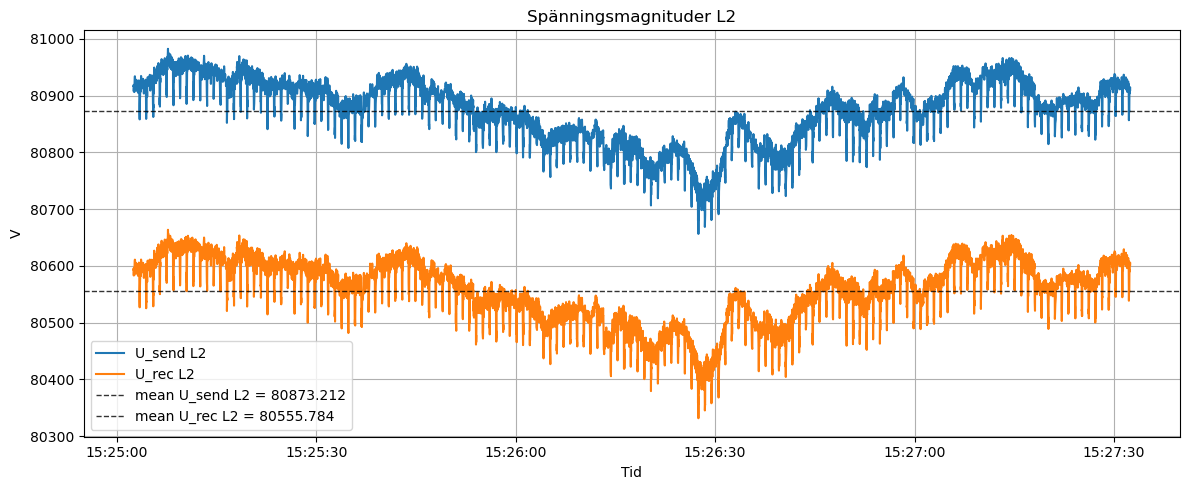

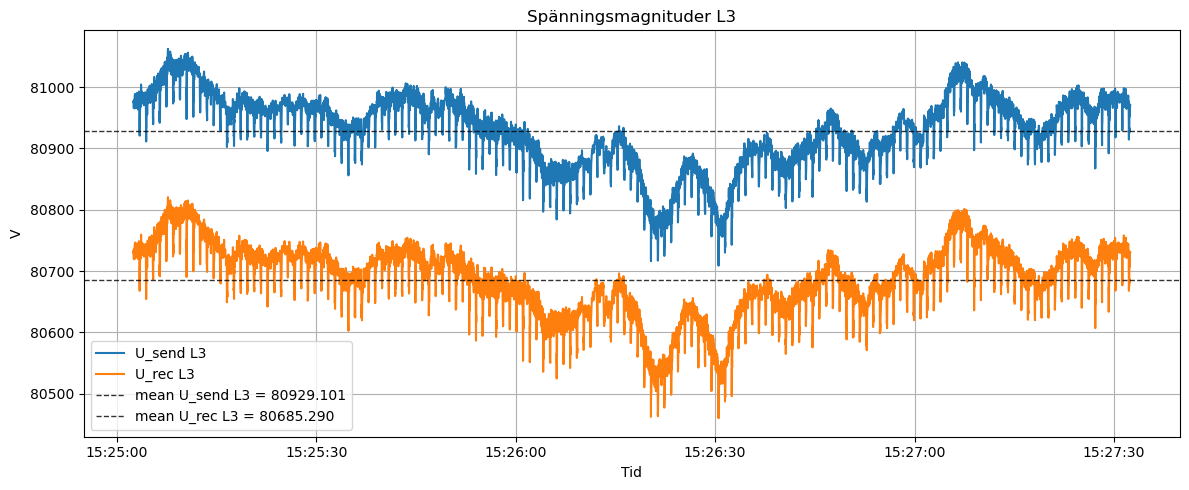

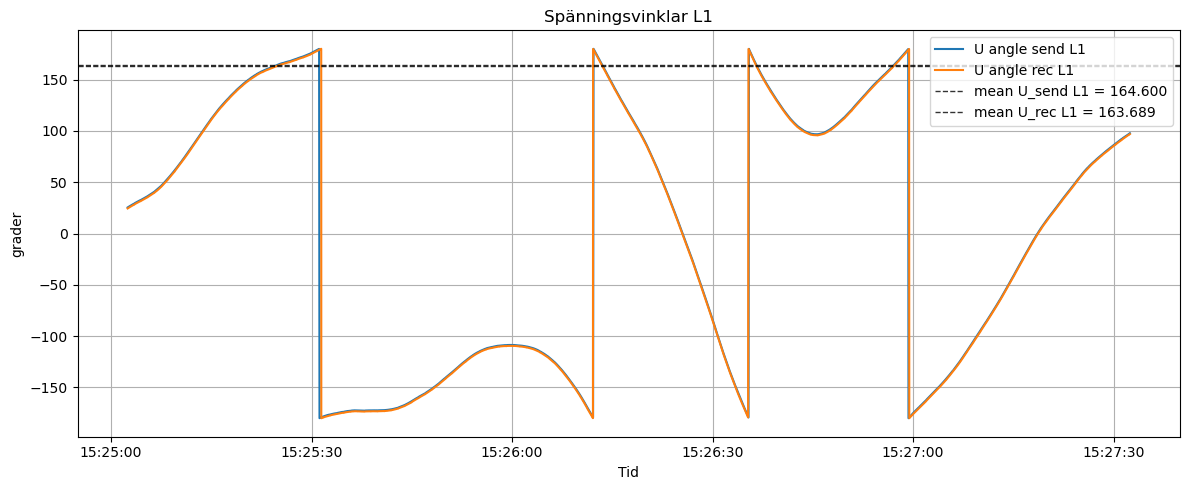

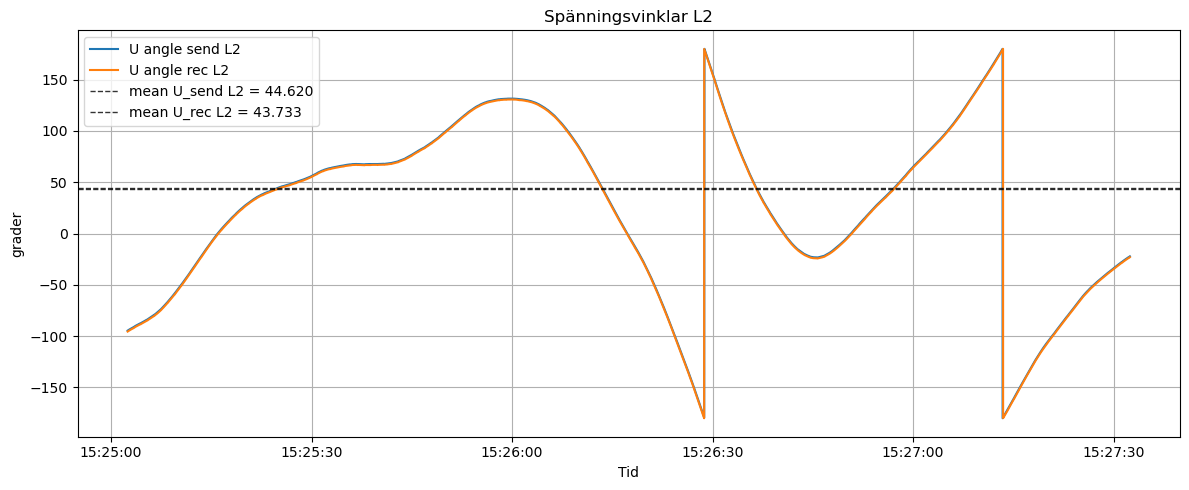

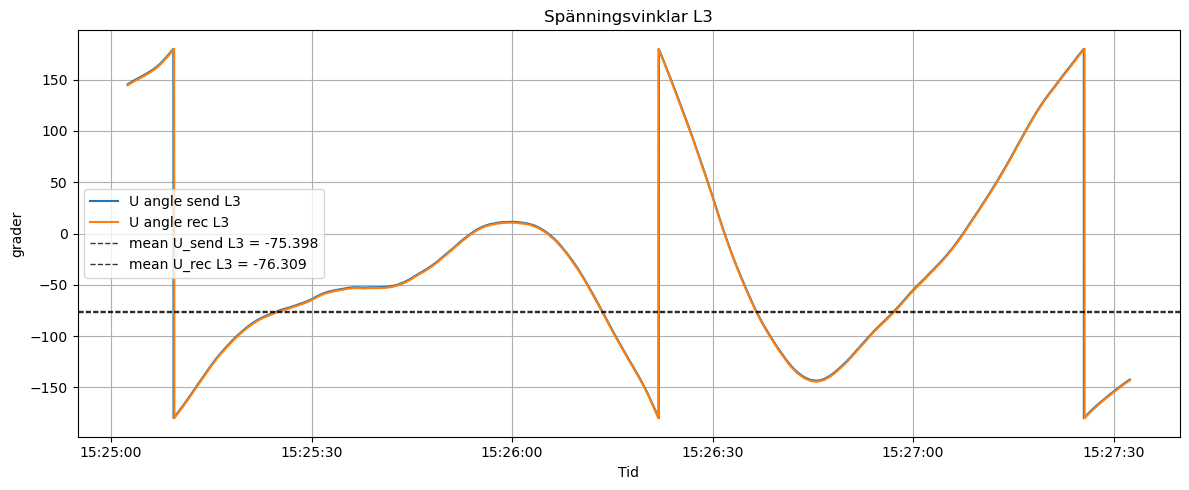

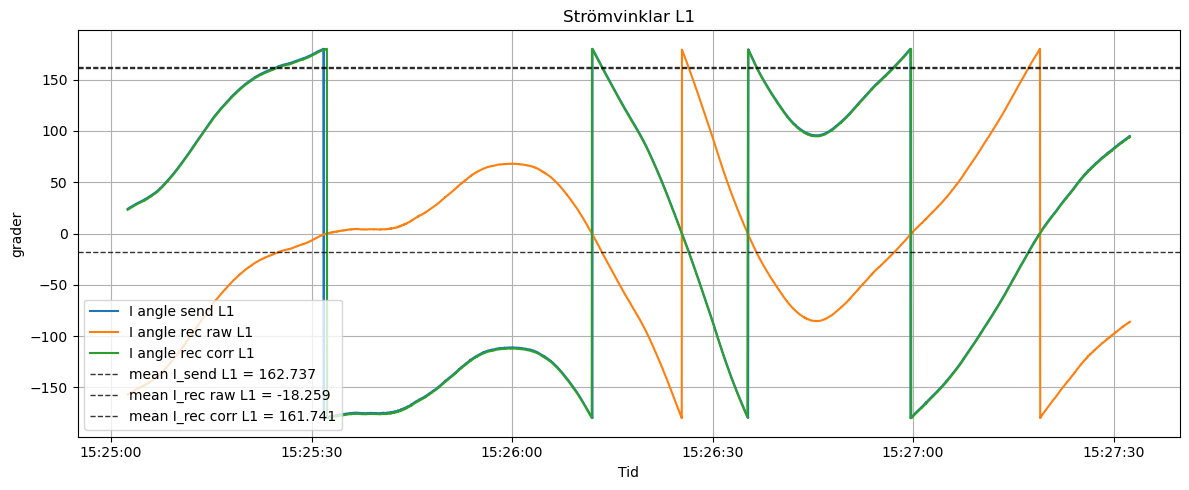

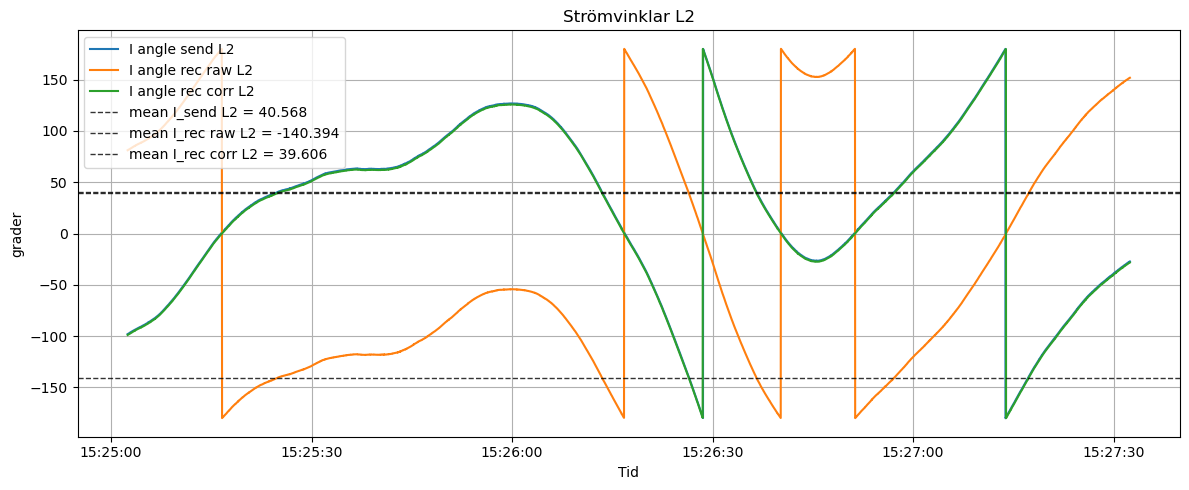

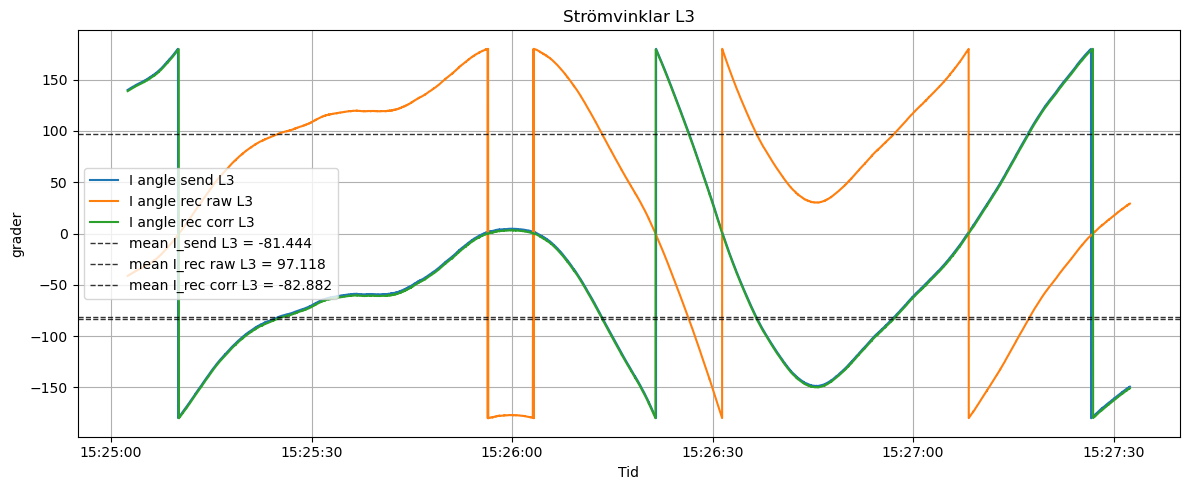

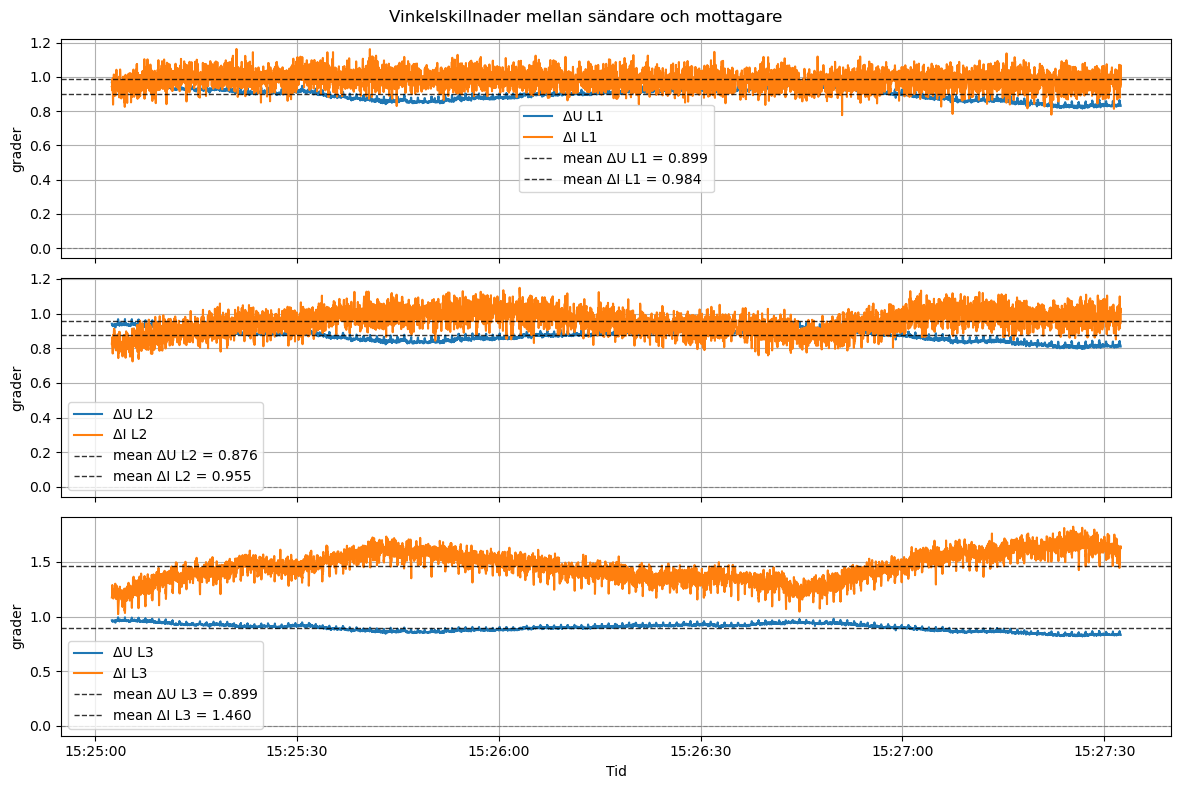

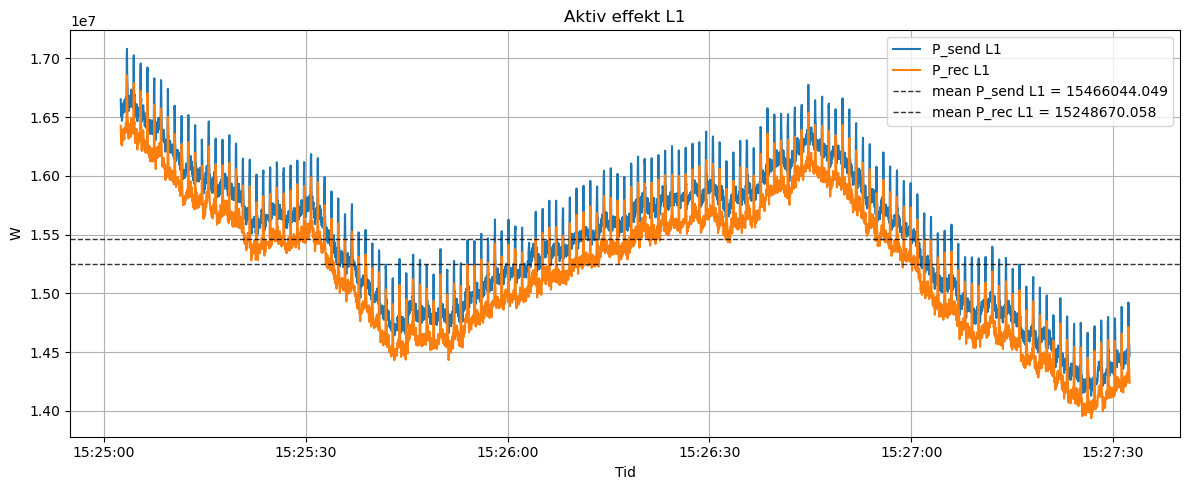

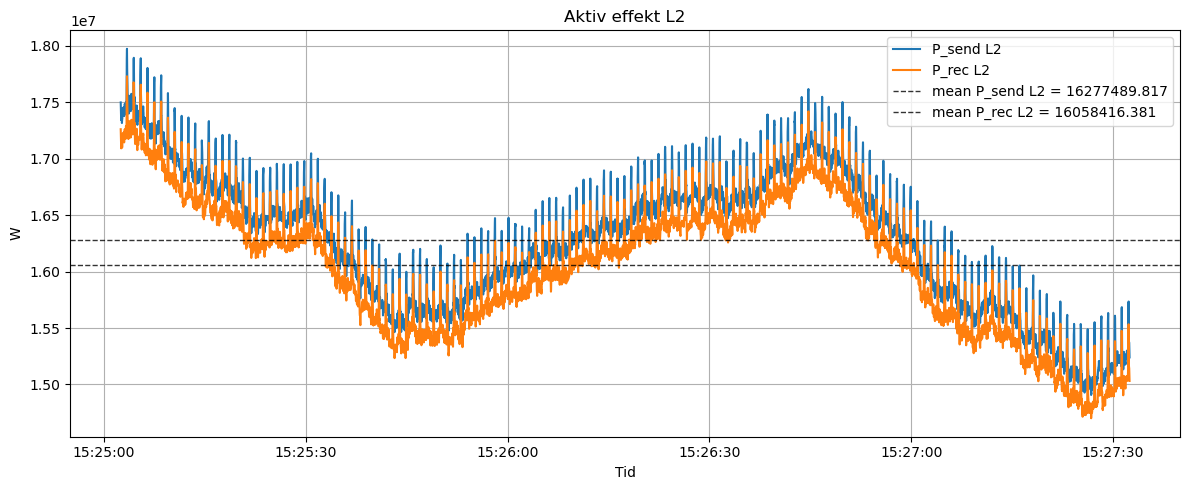

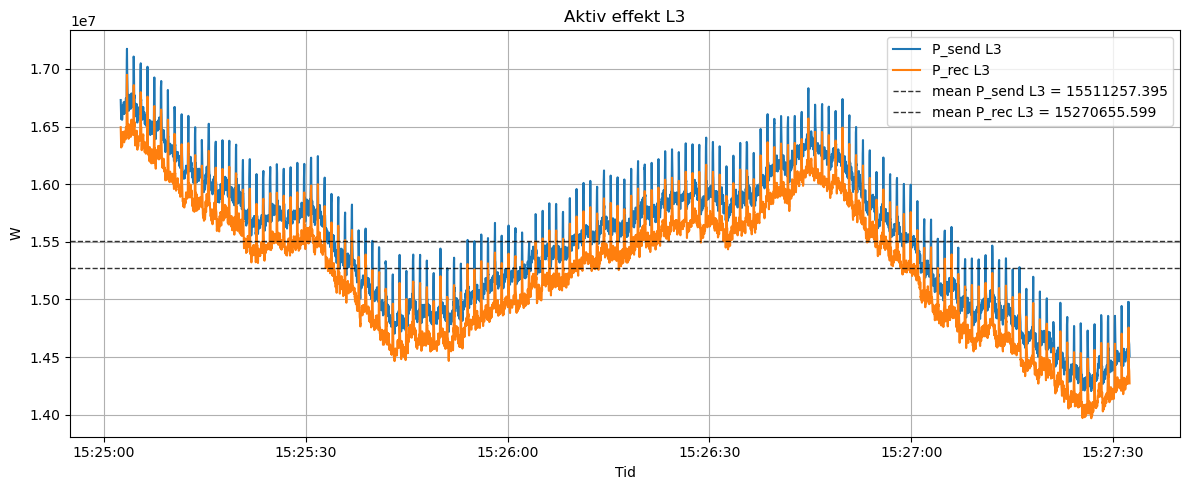

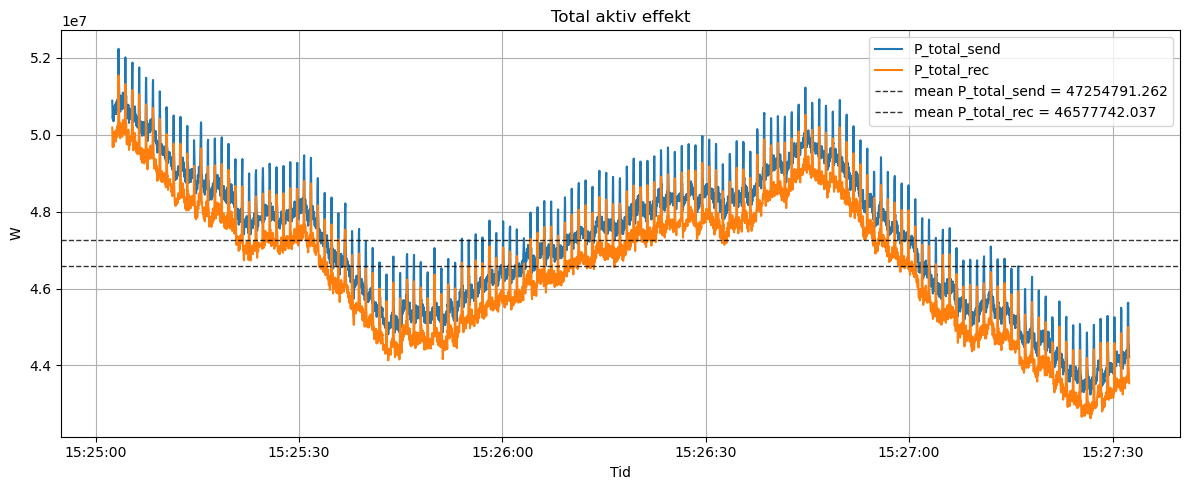

In [2]:
# ============================================================
# PLOTTA DET HANDLEDARNA VILL SE FÖRST:
# STRÖM, SPÄNNING, VINKLAR OCH EFFEKT
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def add_mean_line(ax, y, label_prefix="mean", circular=False, color="black"):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

# ============================================================
# 1. LÄS OCH MAPPA DATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = read_data_table_safe(send_file, dataS_sheet)
rec  = read_data_table_safe(rec_file, dataR_sheet)

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S").sort_index()
wideR = wideR.add_suffix("_R").sort_index()

df_joined = wideS.join(wideR, how="inner").copy()

required_cols = []
for ph in ["L1", "L2", "L3"]:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_joined.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

df_joined = df_joined.dropna(subset=required_cols).copy()

# filtrera bort orimliga vinkelvärden
angle_cols = [c for c in df_joined.columns if "ANG" in c]
for c in angle_cols:
    df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

print("Antal synkade tidssteg:", len(df_joined))
print("Start:", df_joined.index.min())
print("Slut :", df_joined.index.max())

# ============================================================
# 2. BYGG TABELL MED STRÖM/SPÄNNING/VINKLAR/EFFEKT
# ============================================================

out = pd.DataFrame(index=df_joined.index)

for ph in ["L1", "L2", "L3"]:
    # råa magnituder och vinklar
    out[f"U_mag_S_{ph}"] = df_joined[f"U{ph}MAG_S"]
    out[f"U_mag_R_{ph}"] = df_joined[f"U{ph}MAG_R"]
    out[f"I_mag_S_{ph}"] = df_joined[f"I{ph}MAG_S"]
    out[f"I_mag_R_{ph}"] = df_joined[f"I{ph}MAG_R"]

    out[f"U_ang_S_{ph}"] = df_joined[f"U{ph}ANG_S"]
    out[f"U_ang_R_{ph}"] = df_joined[f"U{ph}ANG_R"]
    out[f"I_ang_S_{ph}"] = df_joined[f"I{ph}ANG_S"]
    out[f"I_ang_R_raw_{ph}"] = df_joined[f"I{ph}ANG_R"]

    # korrigera mottagarström med 180°
    out[f"I_ang_R_corr_{ph}"] = wrap_angle_deg(df_joined[f"I{ph}ANG_R"] + 180.0)

    # komplexa storheter
    Vs = complex_from_mag_ang(out[f"U_mag_S_{ph}"], out[f"U_ang_S_{ph}"])
    Vr = complex_from_mag_ang(out[f"U_mag_R_{ph}"], out[f"U_ang_R_{ph}"])

    Is = complex_from_mag_ang(out[f"I_mag_S_{ph}"], out[f"I_ang_S_{ph}"])
    Ir_corr = complex_from_mag_ang(out[f"I_mag_R_{ph}"], out[f"I_ang_R_corr_{ph}"])

    # aktiv effekt
    out[f"P_send_{ph}"] = np.real(Vs * np.conj(Is))
    out[f"P_rec_{ph}"]  = np.real(Vr * np.conj(Ir_corr))

    # vinkelrelationer
    out[f"dU_{ph}"] = wrap_angle_deg(out[f"U_ang_S_{ph}"] - out[f"U_ang_R_{ph}"])
    out[f"dI_{ph}"] = wrap_angle_deg(out[f"I_ang_S_{ph}"] - out[f"I_ang_R_corr_{ph}"])

out["P_total_send"] = out[[f"P_send_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)
out["P_total_rec"]  = out[[f"P_rec_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)

# ============================================================
# 3. SAMMANFATTNINGSTABELL
# ============================================================

summary_rows = []
for ph in ["L1", "L2", "L3"]:
    summary_rows.append({
        "Phase": ph,
        "U_send_mean": np.nanmean(out[f"U_mag_S_{ph}"]),
        "U_rec_mean": np.nanmean(out[f"U_mag_R_{ph}"]),
        "I_send_mean": np.nanmean(out[f"I_mag_S_{ph}"]),
        "I_rec_mean": np.nanmean(out[f"I_mag_R_{ph}"]),
        "U_ang_send_mean_deg": circular_mean_deg(out[f"U_ang_S_{ph}"]),
        "U_ang_rec_mean_deg": circular_mean_deg(out[f"U_ang_R_{ph}"]),
        "I_ang_send_mean_deg": circular_mean_deg(out[f"I_ang_S_{ph}"]),
        "I_ang_rec_raw_mean_deg": circular_mean_deg(out[f"I_ang_R_raw_{ph}"]),
        "I_ang_rec_corr_mean_deg": circular_mean_deg(out[f"I_ang_R_corr_{ph}"]),
        "dU_mean_deg": circular_mean_deg(out[f"dU_{ph}"]),
        "dI_mean_deg": circular_mean_deg(out[f"dI_{ph}"]),
        "P_send_mean_W": np.nanmean(out[f"P_send_{ph}"]),
        "P_rec_mean_W": np.nanmean(out[f"P_rec_{ph}"]),
    })

summary_df = pd.DataFrame(summary_rows)

print("\nSAMMANFATTNING:")
display(summary_df)

# ============================================================
# 4. SPARA RESULTAT
# ============================================================

VERSION = "overview_currents_voltages_angles_power"
output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

out.reset_index().to_excel(output_dir / "overview_raw_quantities.xlsx", index=False)
summary_df.to_excel(output_dir / "overview_summary.xlsx", index=False)

print("Sparat till:", output_dir)

# ============================================================
# 5. PLOTTA STRÖMMAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_mag_S_{ph}"], label=f"I_send {ph}")
    ax.plot(out.index, out[f"I_mag_R_{ph}"], label=f"I_rec {ph}")
    add_mean_line(ax, out[f"I_mag_S_{ph}"], label_prefix=f"mean I_send {ph}")
    add_mean_line(ax, out[f"I_mag_R_{ph}"], label_prefix=f"mean I_rec {ph}")
    ax.set_title(f"Strömmagnituder {ph}")
    ax.set_ylabel("A")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_current_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 6. PLOTTA SPÄNNINGAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_mag_S_{ph}"], label=f"U_send {ph}")
    ax.plot(out.index, out[f"U_mag_R_{ph}"], label=f"U_rec {ph}")
    add_mean_line(ax, out[f"U_mag_S_{ph}"], label_prefix=f"mean U_send {ph}")
    add_mean_line(ax, out[f"U_mag_R_{ph}"], label_prefix=f"mean U_rec {ph}")
    ax.set_title(f"Spänningsmagnituder {ph}")
    ax.set_ylabel("V")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_voltage_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 7. PLOTTA SPÄNNINGSVINKLAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_ang_S_{ph}"], label=f"U angle send {ph}")
    ax.plot(out.index, out[f"U_ang_R_{ph}"], label=f"U angle rec {ph}")
    add_mean_line(ax, out[f"U_ang_S_{ph}"], label_prefix=f"mean U_send {ph}", circular=True)
    add_mean_line(ax, out[f"U_ang_R_{ph}"], label_prefix=f"mean U_rec {ph}", circular=True)
    ax.set_title(f"Spänningsvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_U_angles_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 8. PLOTTA STRÖMVINKLAR (RAW + CORR)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_ang_S_{ph}"], label=f"I angle send {ph}")
    ax.plot(out.index, out[f"I_ang_R_raw_{ph}"], label=f"I angle rec raw {ph}")
    ax.plot(out.index, out[f"I_ang_R_corr_{ph}"], label=f"I angle rec corr {ph}")
    add_mean_line(ax, out[f"I_ang_S_{ph}"], label_prefix=f"mean I_send {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_raw_{ph}"], label_prefix=f"mean I_rec raw {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_corr_{ph}"], label_prefix=f"mean I_rec corr {ph}", circular=True)
    ax.set_title(f"Strömvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_I_angles_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 9. PLOTTA VINKELSKILLNADER
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, out[f"dU_{ph}"], label=f"ΔU {ph}")
    axs[i].plot(out.index, out[f"dI_{ph}"], label=f"ΔI {ph}")
    add_mean_line(axs[i], out[f"dU_{ph}"], label_prefix=f"mean ΔU {ph}", circular=True)
    add_mean_line(axs[i], out[f"dI_{ph}"], label_prefix=f"mean ΔI {ph}", circular=True)
    axs[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("grader")
axs[-1].set_xlabel("Tid")
fig.suptitle("Vinkelskillnader mellan sändare och mottagare")
fig.tight_layout()
fig.savefig(output_dir / "plot_angle_differences.png", dpi=200)
plt.show()

# ============================================================
# 10. PLOTTA AKTIV EFFEKT PER FAS
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"P_send_{ph}"], label=f"P_send {ph}")
    ax.plot(out.index, out[f"P_rec_{ph}"], label=f"P_rec {ph}")
    add_mean_line(ax, out[f"P_send_{ph}"], label_prefix=f"mean P_send {ph}")
    add_mean_line(ax, out[f"P_rec_{ph}"], label_prefix=f"mean P_rec {ph}")
    ax.set_title(f"Aktiv effekt {ph}")
    ax.set_ylabel("W")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_power_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 11. PLOTTA TOTAL AKTIV EFFEKT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(out.index, out["P_total_send"], label="P_total_send")
ax.plot(out.index, out["P_total_rec"], label="P_total_rec")
add_mean_line(ax, out["P_total_send"], label_prefix="mean P_total_send")
add_mean_line(ax, out["P_total_rec"], label_prefix="mean P_total_rec")
ax.set_title("Total aktiv effekt")
ax.set_ylabel("W")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_power_total.png", dpi=200)
plt.show()

SAMMANFATTNING phi och cos(phi):


,Phase,phi_send_mean_deg,phi_rec_mean_deg,cosphi_send_mean,cosphi_rec_mean,phi_send_std_deg,phi_rec_std_deg
0,L1,2.093927,2.179574,0.999271,0.999208,0.635084,0.672977
1,L2,4.287354,4.365929,0.997141,0.997023,0.631091,0.703245
2,L3,6.290655,6.851677,0.993912,0.992758,0.665486,0.813425


Sparat phi-tabeller i: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\overview_currents_voltages_angles_power


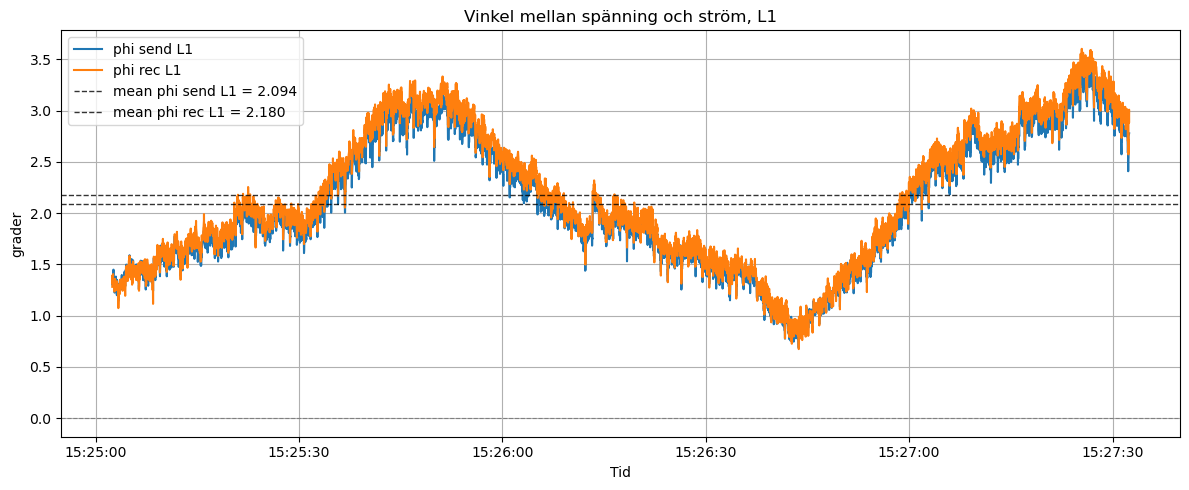

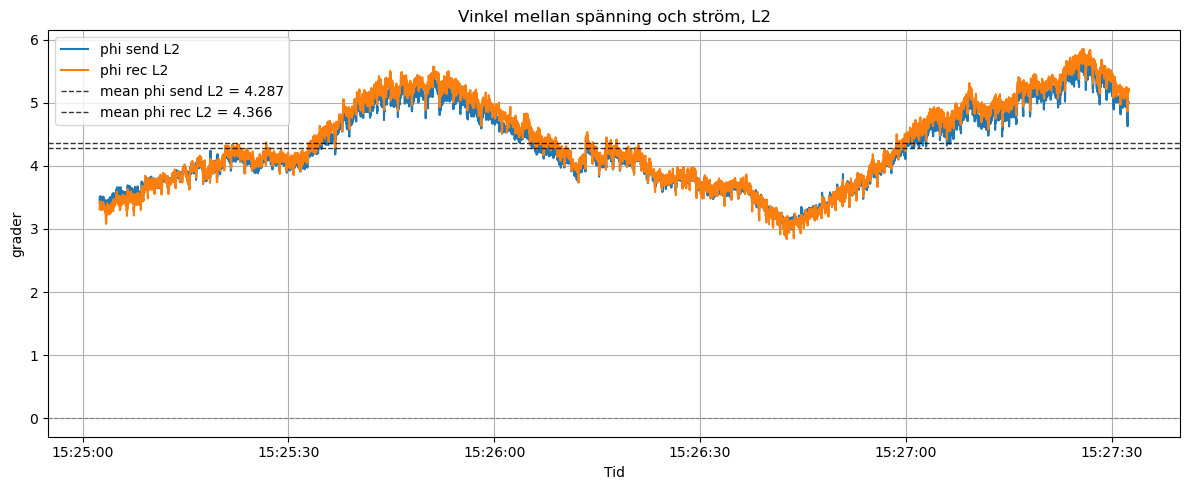

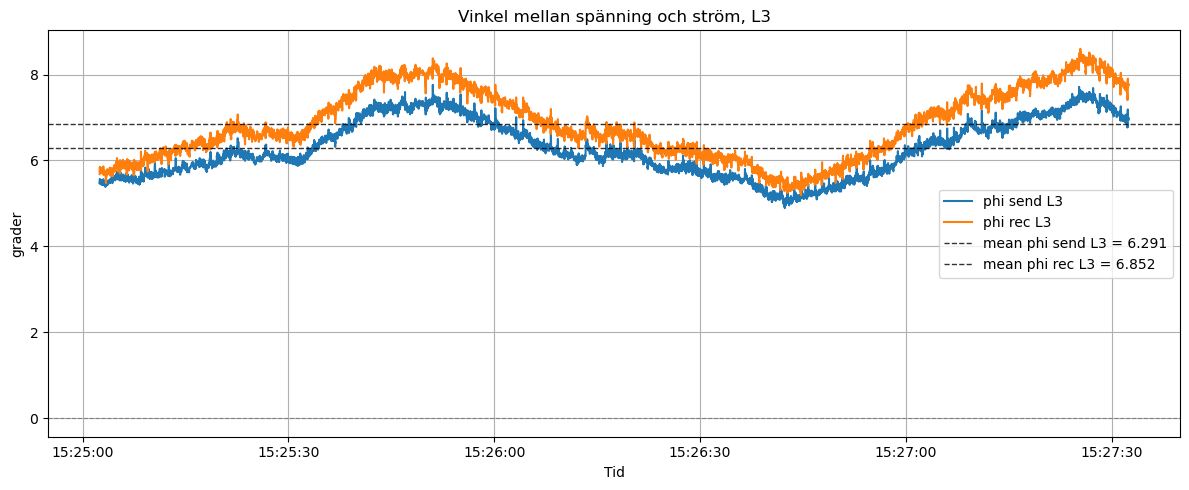

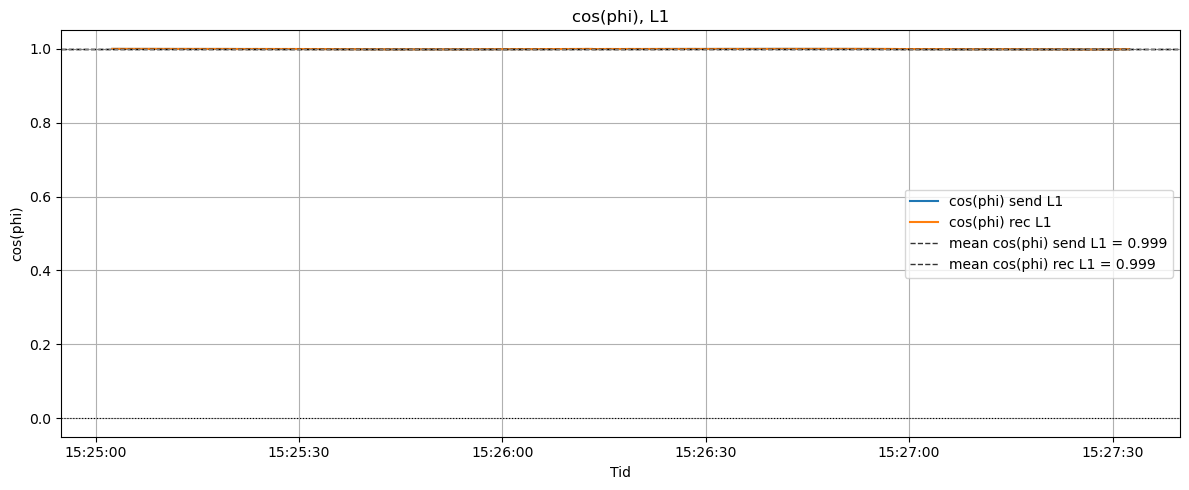

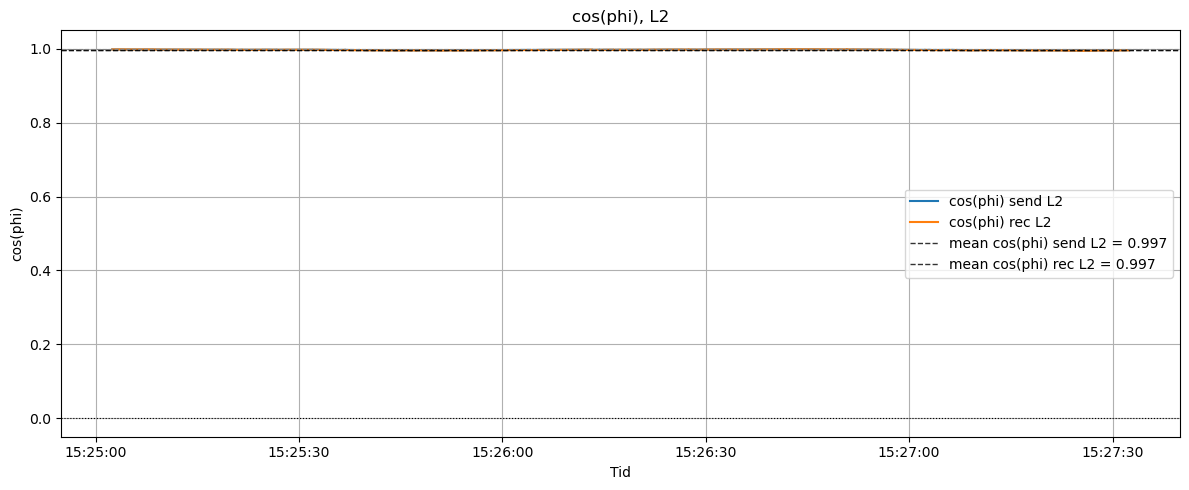

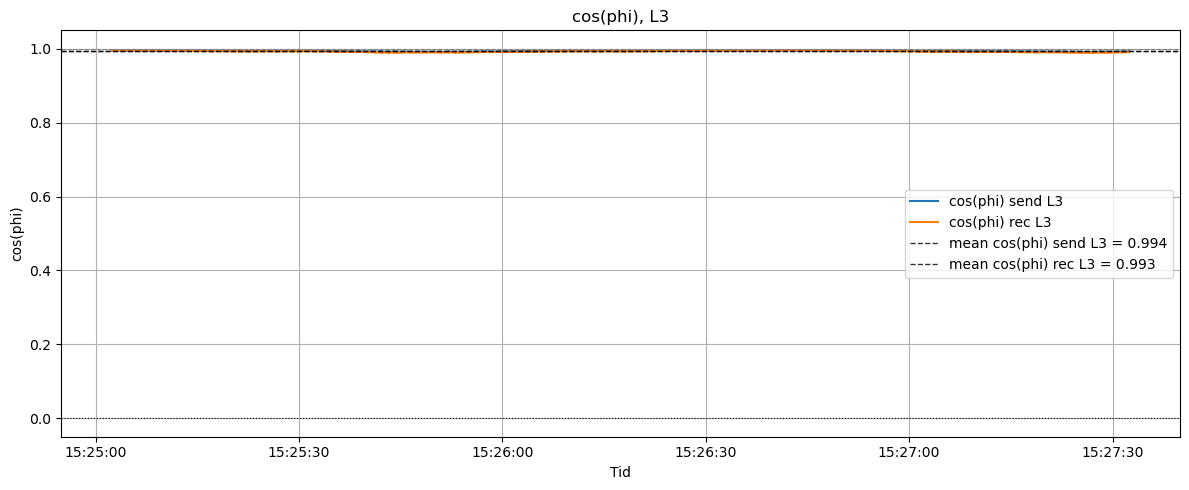

In [3]:
# ============================================================
# BERÄKNA VINKELN MELLAN SPÄNNING OCH STRÖM SAMT cos(phi)
# Kör denna EFTER att 'out' redan finns
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Kontroll
required_cols_phi = []
for ph in ["L1", "L2", "L3"]:
    required_cols_phi += [
        f"U_ang_S_{ph}", f"U_ang_R_{ph}",
        f"I_ang_S_{ph}", f"I_ang_R_corr_{ph}"
    ]

missing_phi = [c for c in required_cols_phi if c not in out.columns]
if missing_phi:
    raise ValueError(f"Saknade kolumner i 'out': {missing_phi}")

# ============================================================
# 1. BERÄKNINGAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    # vinkel mellan U och I i send
    out[f"phi_send_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_S_{ph}"] - out[f"I_ang_S_{ph}"])
    
    # vinkel mellan U och I i receiver (med korrigerad mottagarström)
    out[f"phi_rec_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_R_{ph}"] - out[f"I_ang_R_corr_{ph}"])
    
    # cos(phi)
    out[f"cosphi_send_{ph}"] = np.cos(np.deg2rad(out[f"phi_send_deg_{ph}"]))
    out[f"cosphi_rec_{ph}"]  = np.cos(np.deg2rad(out[f"phi_rec_deg_{ph}"]))

# ============================================================
# 2. SAMMANFATTNINGSTABELL
# ============================================================

phi_rows = []
for ph in ["L1", "L2", "L3"]:
    phi_rows.append({
        "Phase": ph,
        "phi_send_mean_deg": circular_mean_deg(out[f"phi_send_deg_{ph}"]),
        "phi_rec_mean_deg": circular_mean_deg(out[f"phi_rec_deg_{ph}"]),
        "cosphi_send_mean": np.nanmean(out[f"cosphi_send_{ph}"]),
        "cosphi_rec_mean": np.nanmean(out[f"cosphi_rec_{ph}"]),
        "phi_send_std_deg": np.nanstd(out[f"phi_send_deg_{ph}"]),
        "phi_rec_std_deg": np.nanstd(out[f"phi_rec_deg_{ph}"]),
    })

phi_summary_df = pd.DataFrame(phi_rows)

print("SAMMANFATTNING phi och cos(phi):")
display(phi_summary_df)

# ============================================================
# 3. SPARA TABELL
# ============================================================

try:
    phi_summary_df.to_excel(output_dir / "phi_cosphi_summary.xlsx", index=False)
    out.reset_index().to_excel(output_dir / "overview_with_phi.xlsx", index=False)
    print("Sparat phi-tabeller i:", output_dir)
except Exception as e:
    print("Kunde inte spara filer:", e)

# ============================================================
# 4. PLOTTA phi (grader)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"phi_send_deg_{ph}"], label=f"phi send {ph}")
    ax.plot(out.index, out[f"phi_rec_deg_{ph}"], label=f"phi rec {ph}")
    add_mean_line(ax, out[f"phi_send_deg_{ph}"], label_prefix=f"mean phi send {ph}", circular=True)
    add_mean_line(ax, out[f"phi_rec_deg_{ph}"], label_prefix=f"mean phi rec {ph}", circular=True)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Vinkel mellan spänning och ström, {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    try:
        fig.savefig(output_dir / f"plot_phi_{ph}.png", dpi=200)
    except Exception:
        pass
    plt.show()

# ============================================================
# 5. PLOTTA cos(phi)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"cosphi_send_{ph}"], label=f"cos(phi) send {ph}")
    ax.plot(out.index, out[f"cosphi_rec_{ph}"], label=f"cos(phi) rec {ph}")
    add_mean_line(ax, out[f"cosphi_send_{ph}"], label_prefix=f"mean cos(phi) send {ph}")
    add_mean_line(ax, out[f"cosphi_rec_{ph}"], label_prefix=f"mean cos(phi) rec {ph}")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8)
    ax.set_title(f"cos(phi), {ph}")
    ax.set_ylabel("cos(phi)")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    try:
        fig.savefig(output_dir / f"plot_cosphi_{ph}.png", dpi=200)
    except Exception:
        pass
    plt.show()

FASFÖRSKJUTNING MELLAN L1, L2, L3


,Signal,L1-L2 mean deg,L2-L3 mean deg,L3-L1 mean deg
0,U_send,119.977424,120.020442,120.002134
1,U_rec,119.954643,120.043213,120.002144
2,I_send,122.170851,122.023744,115.805405
3,I_rec_corr,122.140998,122.528963,115.330039


Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\overview_currents_voltages_angles_power\phase_shift_summary.xlsx


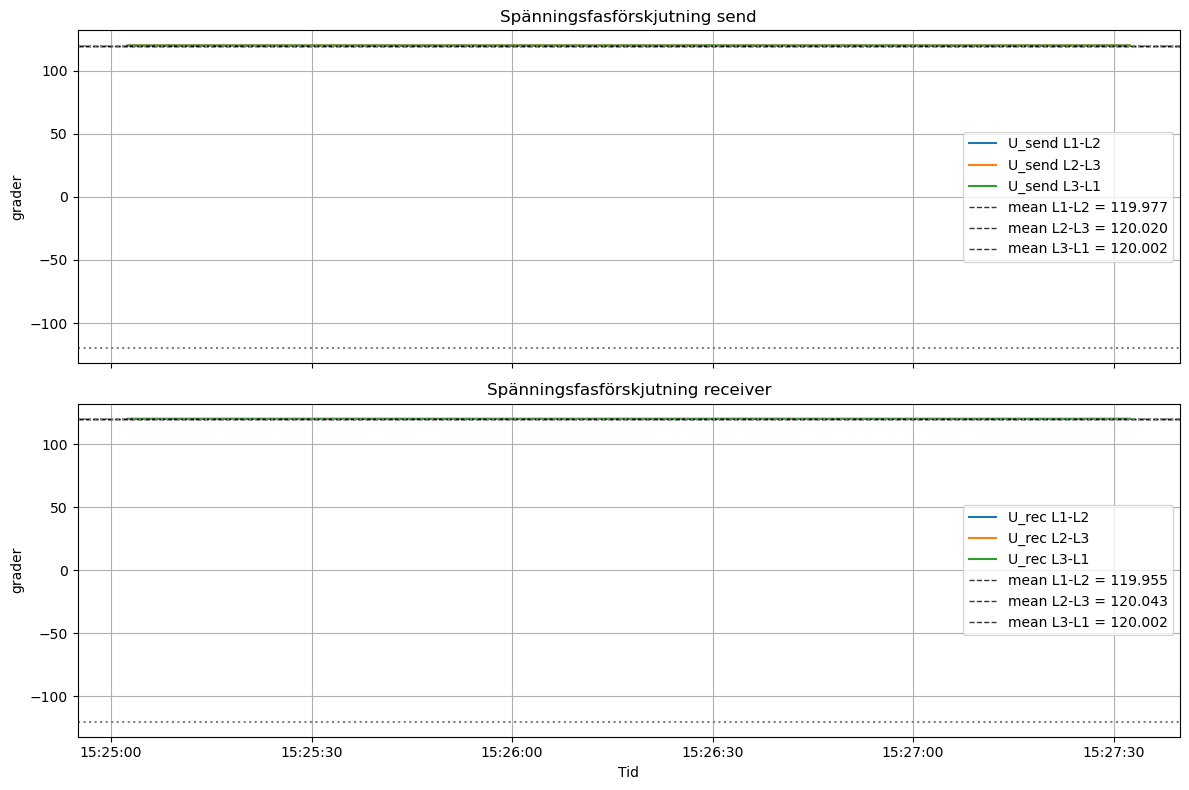

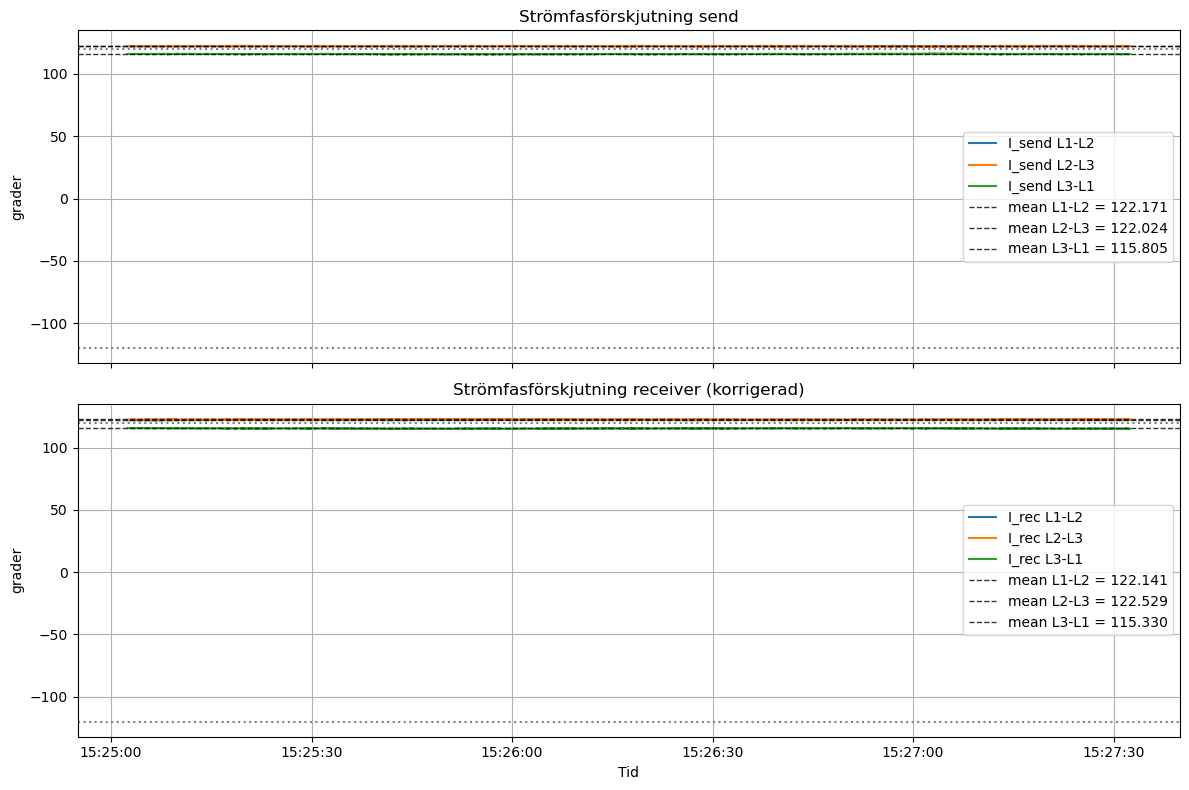

In [4]:
# ============================================================
# VISA FASFÖRSKJUTNING MELLAN L1, L2, L3
# Kör denna efter att 'out' redan finns
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# HJÄLPFUNKTION
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def add_mean_line(ax, y, label_prefix="mean", circular=False, color="black"):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

# ============================================================
# KONTROLLERA ATT VI HAR KOLUMNERNA
# ============================================================

required_phase_cols = [
    "U_ang_S_L1", "U_ang_S_L2", "U_ang_S_L3",
    "U_ang_R_L1", "U_ang_R_L2", "U_ang_R_L3",
    "I_ang_S_L1", "I_ang_S_L2", "I_ang_S_L3",
    "I_ang_R_corr_L1", "I_ang_R_corr_L2", "I_ang_R_corr_L3",
]

missing_cols = [c for c in required_phase_cols if c not in out.columns]
if missing_cols:
    raise ValueError(f"Saknade kolumner i out: {missing_cols}")

# ============================================================
# 1. SPÄNNINGSFASFÖRSKJUTNINGAR
# ============================================================

# Send
out["dU_send_L1_L2"] = wrap_angle_deg(out["U_ang_S_L1"] - out["U_ang_S_L2"])
out["dU_send_L2_L3"] = wrap_angle_deg(out["U_ang_S_L2"] - out["U_ang_S_L3"])
out["dU_send_L3_L1"] = wrap_angle_deg(out["U_ang_S_L3"] - out["U_ang_S_L1"])

# Receiver
out["dU_rec_L1_L2"] = wrap_angle_deg(out["U_ang_R_L1"] - out["U_ang_R_L2"])
out["dU_rec_L2_L3"] = wrap_angle_deg(out["U_ang_R_L2"] - out["U_ang_R_L3"])
out["dU_rec_L3_L1"] = wrap_angle_deg(out["U_ang_R_L3"] - out["U_ang_R_L1"])

# ============================================================
# 2. STRÖMFASFÖRSKJUTNINGAR
# ============================================================

# Send
out["dI_send_L1_L2"] = wrap_angle_deg(out["I_ang_S_L1"] - out["I_ang_S_L2"])
out["dI_send_L2_L3"] = wrap_angle_deg(out["I_ang_S_L2"] - out["I_ang_S_L3"])
out["dI_send_L3_L1"] = wrap_angle_deg(out["I_ang_S_L3"] - out["I_ang_S_L1"])

# Receiver (korrigerade vinklar)
out["dI_rec_L1_L2"] = wrap_angle_deg(out["I_ang_R_corr_L1"] - out["I_ang_R_corr_L2"])
out["dI_rec_L2_L3"] = wrap_angle_deg(out["I_ang_R_corr_L2"] - out["I_ang_R_corr_L3"])
out["dI_rec_L3_L1"] = wrap_angle_deg(out["I_ang_R_corr_L3"] - out["I_ang_R_corr_L1"])

# ============================================================
# 3. SAMMANFATTNINGSTABELL
# ============================================================

phase_shift_summary = pd.DataFrame([
    {
        "Signal": "U_send",
        "L1-L2 mean deg": circular_mean_deg(out["dU_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_send_L3_L1"]),
    },
    {
        "Signal": "U_rec",
        "L1-L2 mean deg": circular_mean_deg(out["dU_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_rec_L3_L1"]),
    },
    {
        "Signal": "I_send",
        "L1-L2 mean deg": circular_mean_deg(out["dI_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_send_L3_L1"]),
    },
    {
        "Signal": "I_rec_corr",
        "L1-L2 mean deg": circular_mean_deg(out["dI_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_rec_L3_L1"]),
    },
])

print("FASFÖRSKJUTNING MELLAN L1, L2, L3")
display(phase_shift_summary)

# ============================================================
# 4. SPARA
# ============================================================

try:
    phase_shift_summary.to_excel(output_dir / "phase_shift_summary.xlsx", index=False)
    print("Sparat till:", output_dir / "phase_shift_summary.xlsx")
except Exception as e:
    print("Kunde inte spara Excel:", e)

# ============================================================
# 5. PLOTTA SPÄNNINGSFASFÖRSKJUTNINGAR
# ============================================================

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Send
axs[0].plot(out.index, out["dU_send_L1_L2"], label="U_send L1-L2")
axs[0].plot(out.index, out["dU_send_L2_L3"], label="U_send L2-L3")
axs[0].plot(out.index, out["dU_send_L3_L1"], label="U_send L3-L1")
add_mean_line(axs[0], out["dU_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dU_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dU_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Spänningsfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

# Receiver
axs[1].plot(out.index, out["dU_rec_L1_L2"], label="U_rec L1-L2")
axs[1].plot(out.index, out["dU_rec_L2_L3"], label="U_rec L2-L3")
axs[1].plot(out.index, out["dU_rec_L3_L1"], label="U_rec L3-L1")
add_mean_line(axs[1], out["dU_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dU_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dU_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Spänningsfasförskjutning receiver")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
try:
    fig.savefig(output_dir / "plot_phase_shift_voltage.png", dpi=200)
except Exception:
    pass
plt.show()

# ============================================================
# 6. PLOTTA STRÖMFASFÖRSKJUTNINGAR
# ============================================================

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Send
axs[0].plot(out.index, out["dI_send_L1_L2"], label="I_send L1-L2")
axs[0].plot(out.index, out["dI_send_L2_L3"], label="I_send L2-L3")
axs[0].plot(out.index, out["dI_send_L3_L1"], label="I_send L3-L1")
add_mean_line(axs[0], out["dI_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dI_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dI_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Strömfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

# Receiver
axs[1].plot(out.index, out["dI_rec_L1_L2"], label="I_rec L1-L2")
axs[1].plot(out.index, out["dI_rec_L2_L3"], label="I_rec L2-L3")
axs[1].plot(out.index, out["dI_rec_L3_L1"], label="I_rec L3-L1")
add_mean_line(axs[1], out["dI_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dI_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dI_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Strömfasförskjutning receiver (korrigerad)")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
try:
    fig.savefig(output_dir / "plot_phase_shift_current.png", dpi=200)
except Exception:
    pass
plt.show()

Relativa fasvinklar mot L1:


,Signal,L1_mean_deg_(±180),L2_mean_deg_(±180),L3_mean_deg_(±180),L1_mean_deg_(0_360),L2_mean_deg_(0_360),L3_mean_deg_(0_360)
0,U_send relativt L1,0.0,-119.977424,120.002134,0.0,240.022576,120.002134


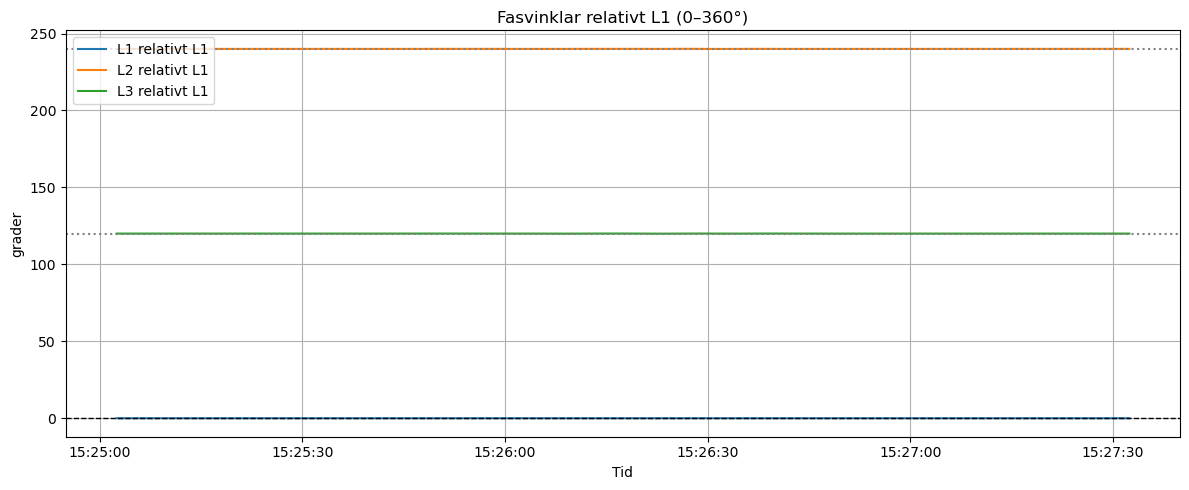

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def to_360(angle_deg):
    return angle_deg % 360.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

# ============================
# Välj vilken signal du vill normalisera
# Exempel: spänning i send
# ============================

U1 = out["U_ang_S_L1"]
U2 = out["U_ang_S_L2"]
U3 = out["U_ang_S_L3"]

# Relativa vinklar mot L1
U1_rel = wrap_angle_deg(U1 - U1)   # alltid 0
U2_rel = wrap_angle_deg(U2 - U1)
U3_rel = wrap_angle_deg(U3 - U1)

# Samma men i intervallet [0, 360)
U1_rel_360 = to_360(U1_rel)
U2_rel_360 = to_360(U2_rel)
U3_rel_360 = to_360(U3_rel)

# Sammanfattning
phase_reference_df = pd.DataFrame([{
    "Signal": "U_send relativt L1",
    "L1_mean_deg_(±180)": circular_mean_deg(U1_rel),
    "L2_mean_deg_(±180)": circular_mean_deg(U2_rel),
    "L3_mean_deg_(±180)": circular_mean_deg(U3_rel),
    "L1_mean_deg_(0_360)": to_360(circular_mean_deg(U1_rel)),
    "L2_mean_deg_(0_360)": to_360(circular_mean_deg(U2_rel)),
    "L3_mean_deg_(0_360)": to_360(circular_mean_deg(U3_rel)),
}])

print("Relativa fasvinklar mot L1:")
display(phase_reference_df)

# Plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(out.index, U1_rel_360, label="L1 relativt L1")
ax.plot(out.index, U2_rel_360, label="L2 relativt L1")
ax.plot(out.index, U3_rel_360, label="L3 relativt L1")

ax.axhline(0, color="black", linestyle="--", linewidth=1.0)
ax.axhline(120, color="gray", linestyle=":")
ax.axhline(240, color="gray", linestyle=":")

ax.set_title("Fasvinklar relativt L1 (0–360°)")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

send finns: True
rec finns : True


C:\Users\lundi\AppData\Local\Temp\ipykernel_156292\1967772652.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_156292\1967772652.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")


Antal synkade tidssteg: 7669
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.450000

SAMMANFATTNING:


,Phase,U_send_mean,U_rec_mean,I_send_mean,I_rec_mean,U_ang_send_mean_deg,U_ang_rec_mean_deg,I_ang_send_mean_deg,I_ang_rec_raw_mean_deg,I_ang_rec_corr_mean_deg,dU_mean_deg,dI_mean_deg,phi_send_mean_deg,phi_rec_mean_deg,cosphi_send_mean,cosphi_rec_mean,P_send_mean_W,P_rec_mean_W
0,L1,80883.253383,80496.368343,191.352329,189.581683,164.599535,163.688732,162.736856,-18.258586,161.741414,0.898770,0.984417,2.093927,2.179574,0.999271,0.999208,1.546604e+07,1.524867e+07
1,L2,80873.212155,80555.784209,201.844450,199.935422,44.619834,43.732696,40.568157,-140.393725,39.606275,0.875989,0.954564,4.287354,4.365929,0.997141,0.997023,1.627749e+07,1.605842e+07
2,L3,80929.100680,80685.289530,192.831843,190.632206,-75.398451,-76.308712,-81.443610,97.118344,-82.881656,0.898759,1.459783,6.290655,6.851677,0.993912,0.992758,1.551126e+07,1.527066e+07



FASFÖRSKJUTNING MELLAN L1, L2, L3:


,Signal,L1-L2 mean deg,L2-L3 mean deg,L3-L1 mean deg,L1 rel 0-360,L2 rel 0-360,L3 rel 0-360
0,U_send,119.977424,120.020442,120.002134,0.0,240.022576,120.002134
1,U_rec,119.954643,120.043213,120.002144,0.0,240.045357,120.002144
2,I_send,122.170851,122.023744,115.805405,0.0,237.829149,115.805405
3,I_rec_corr,122.140998,122.528963,115.330039,0.0,237.859002,115.330039


Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\overview_all_signals_with_phase_reference


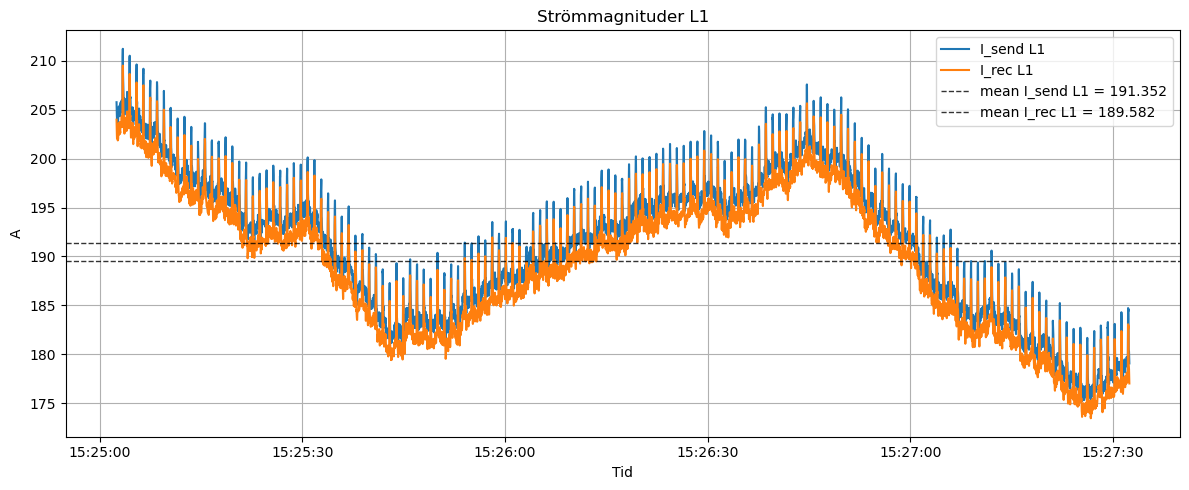

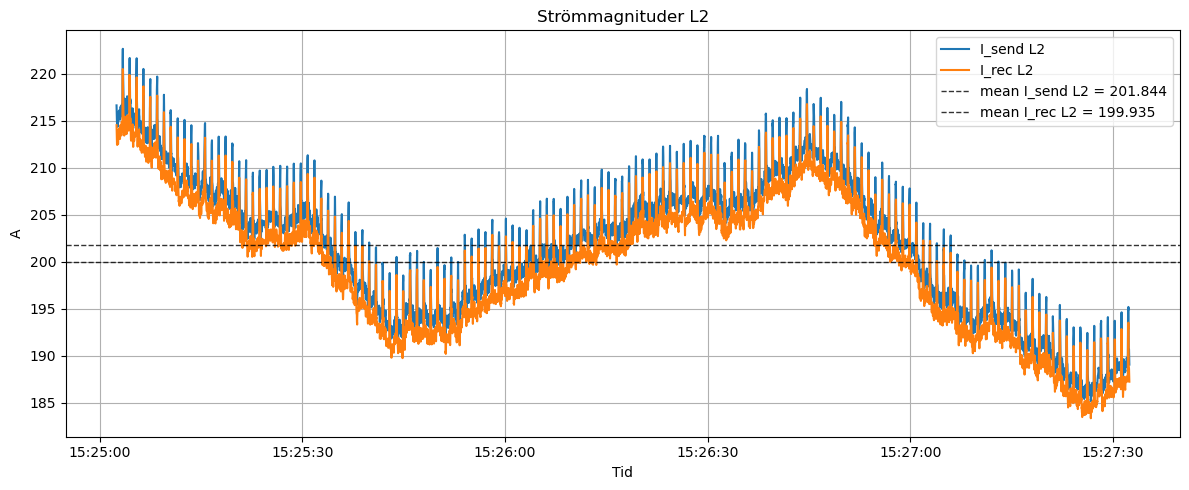

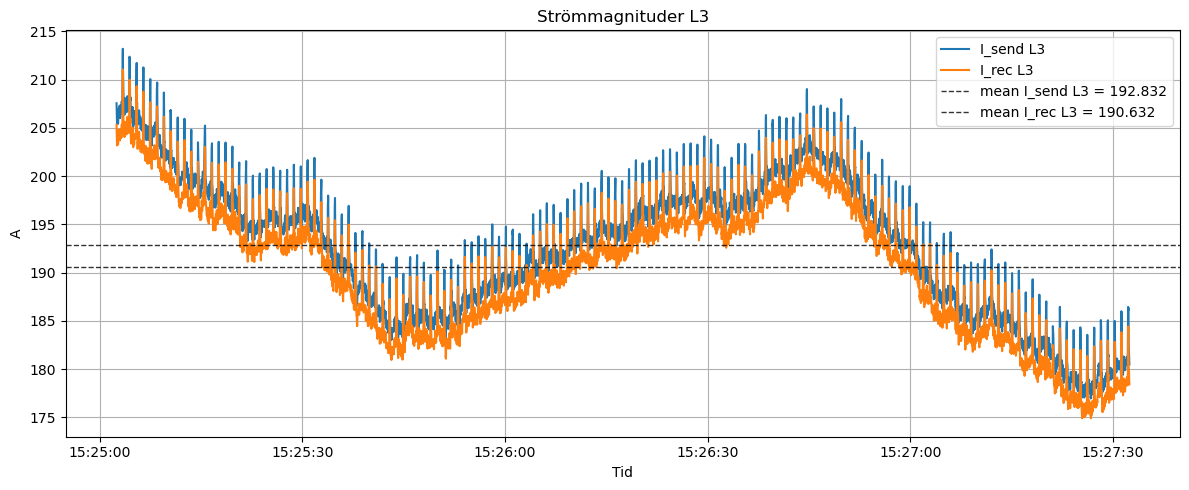

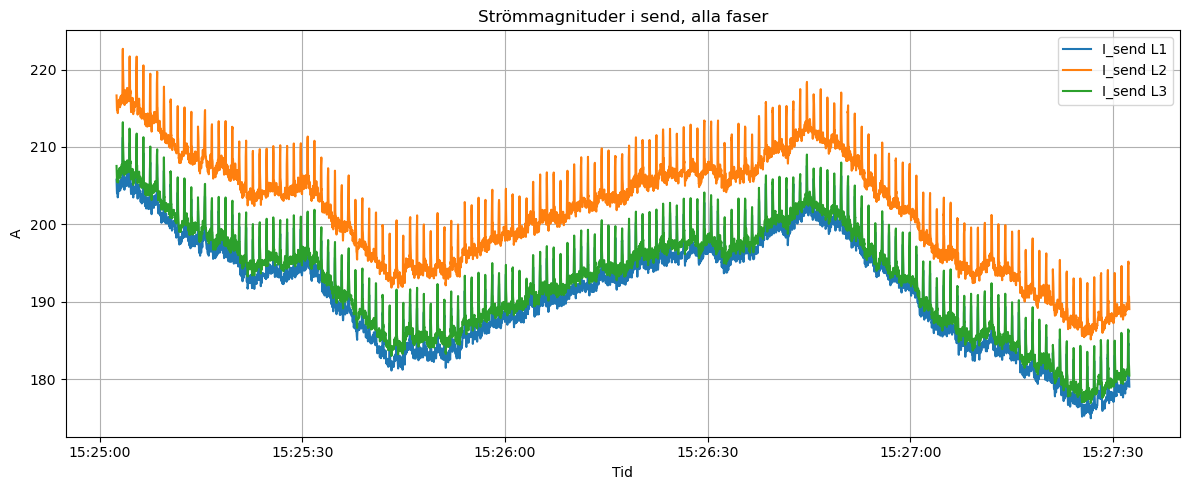

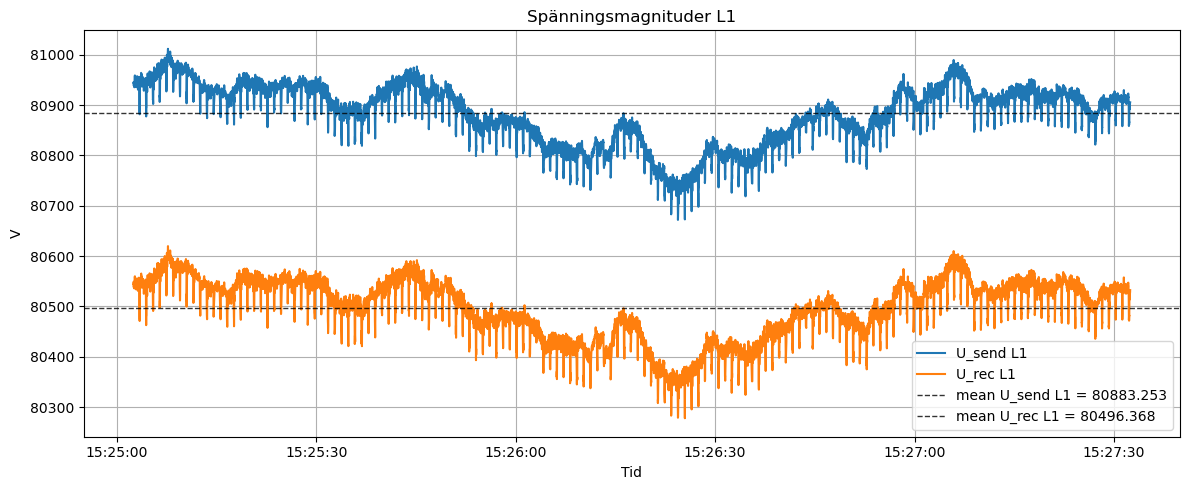

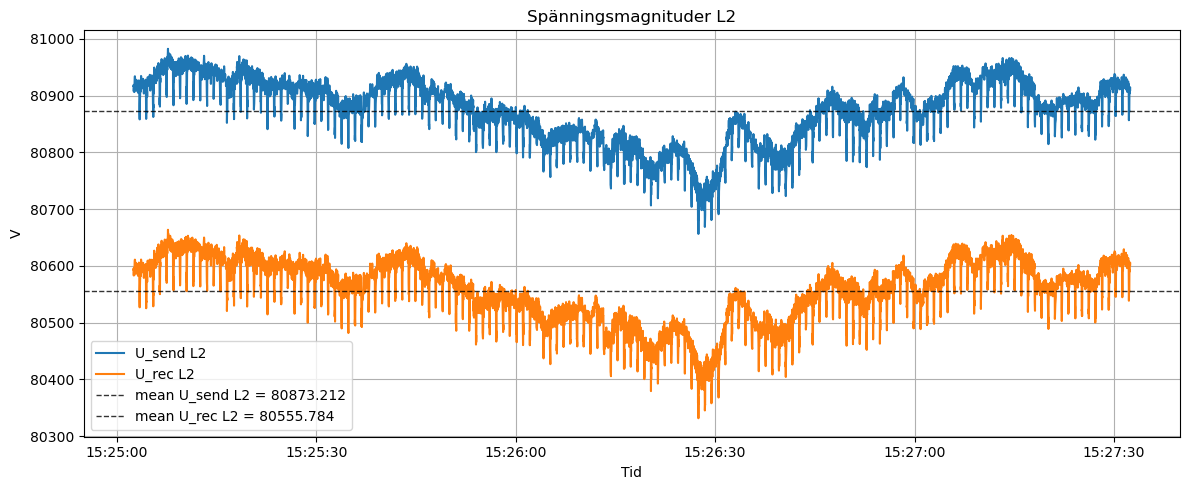

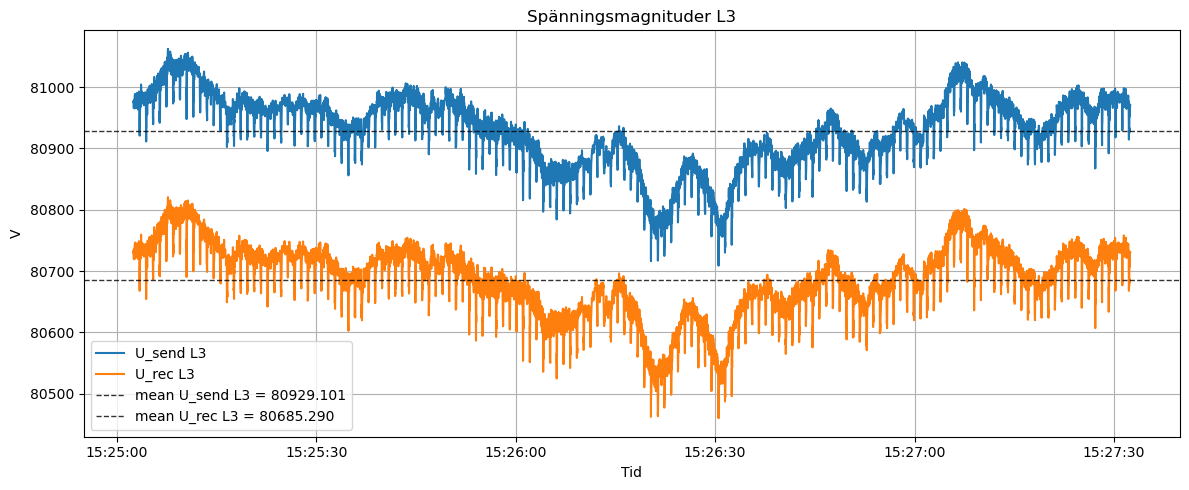

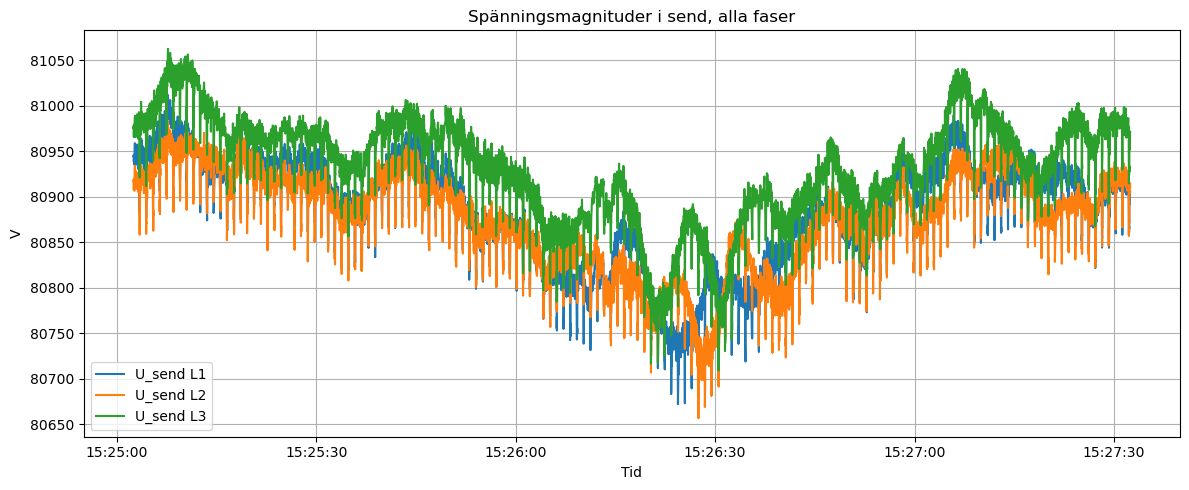

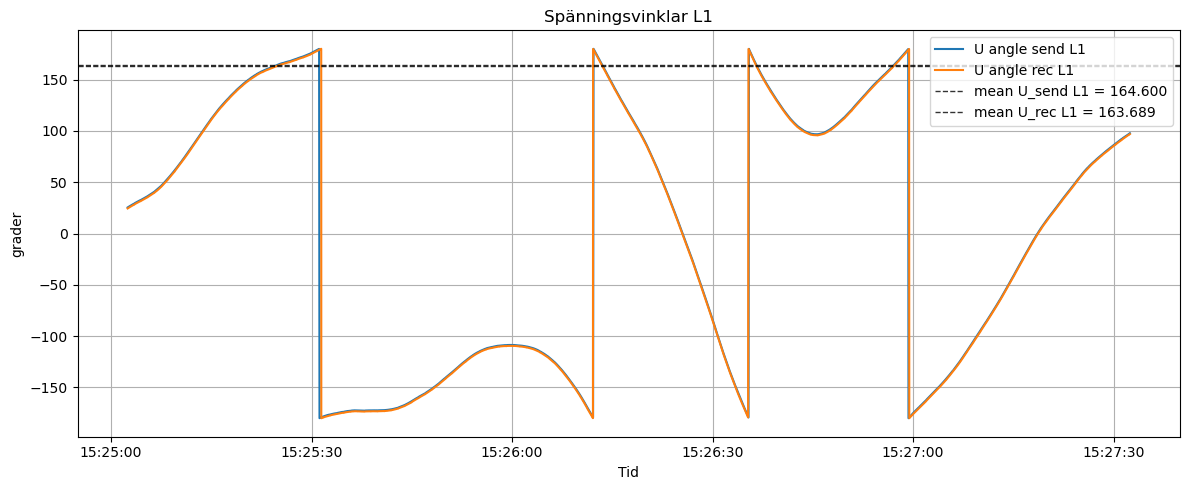

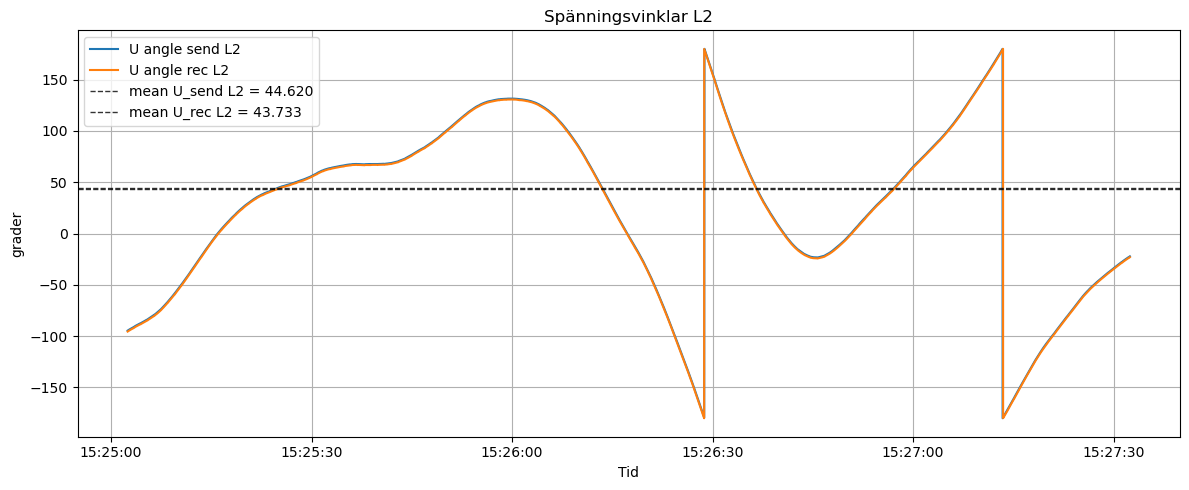

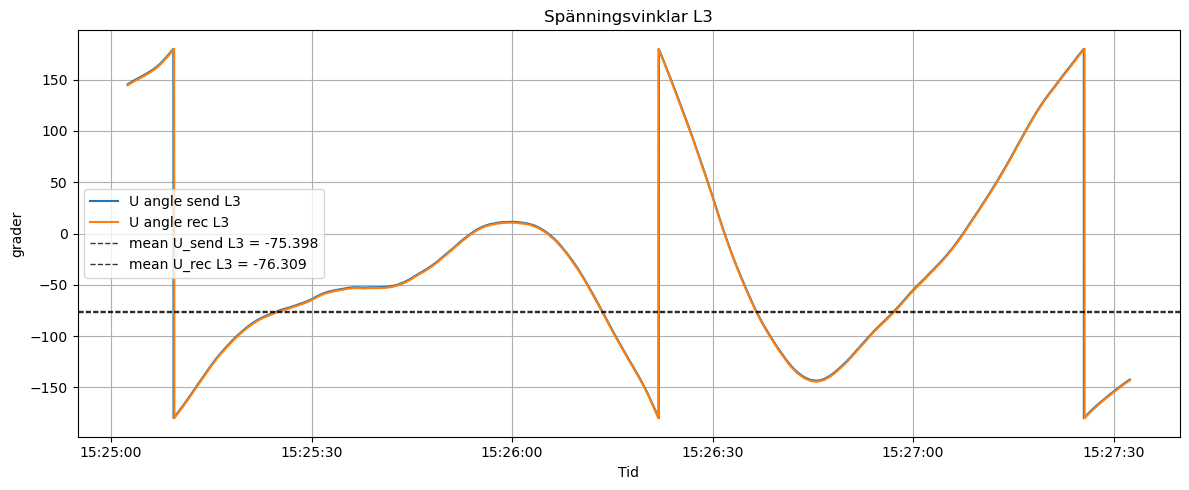

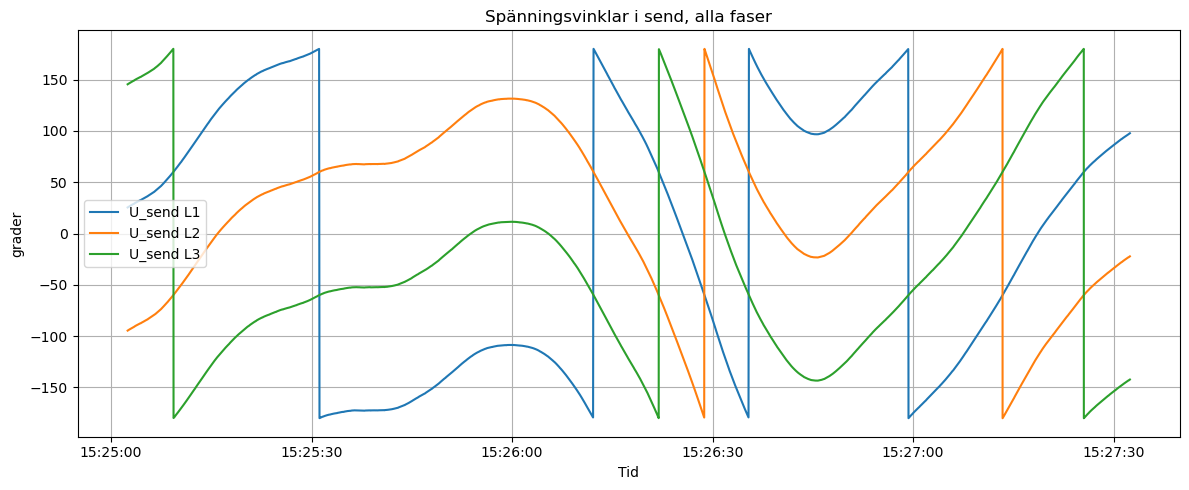

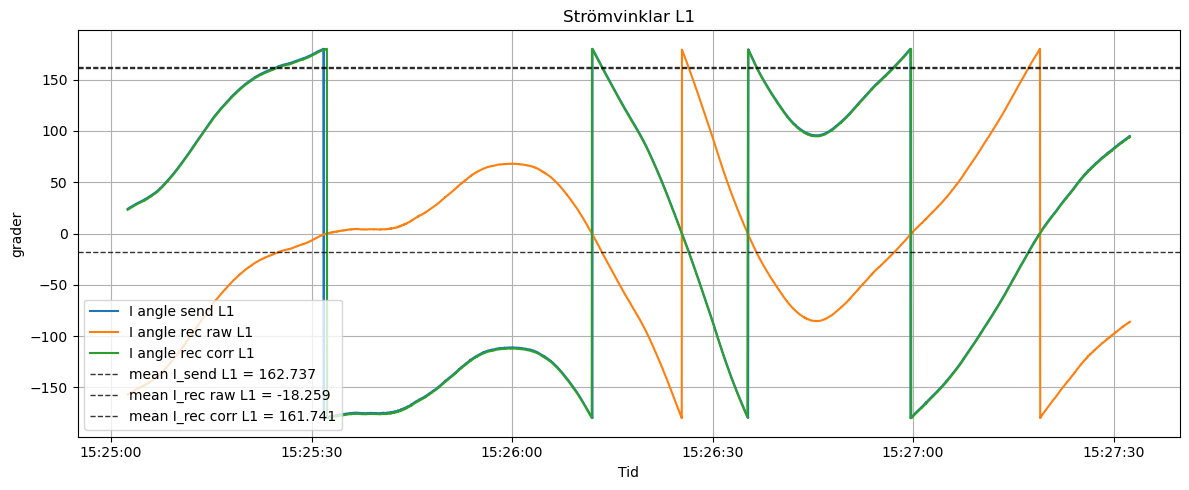

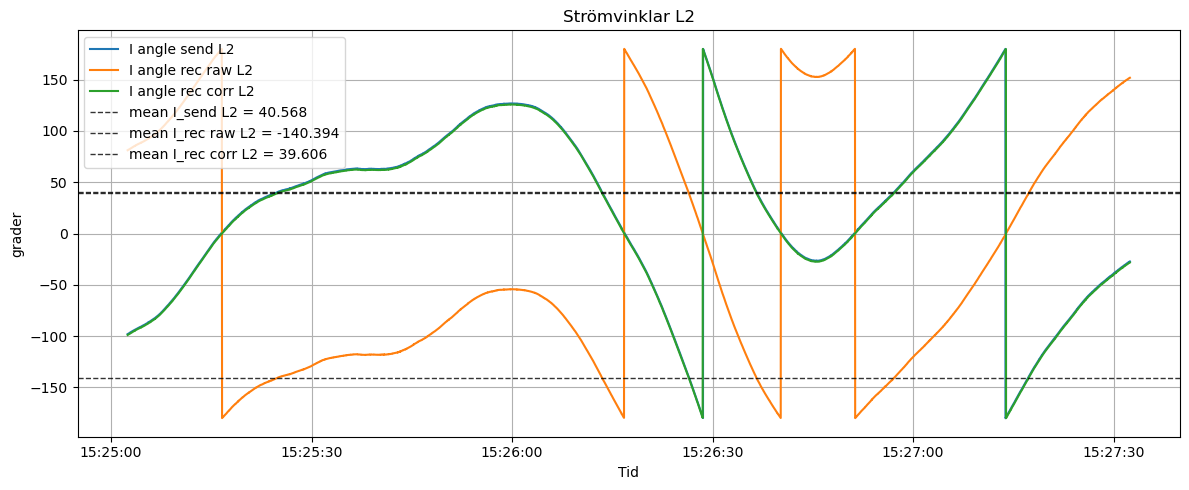

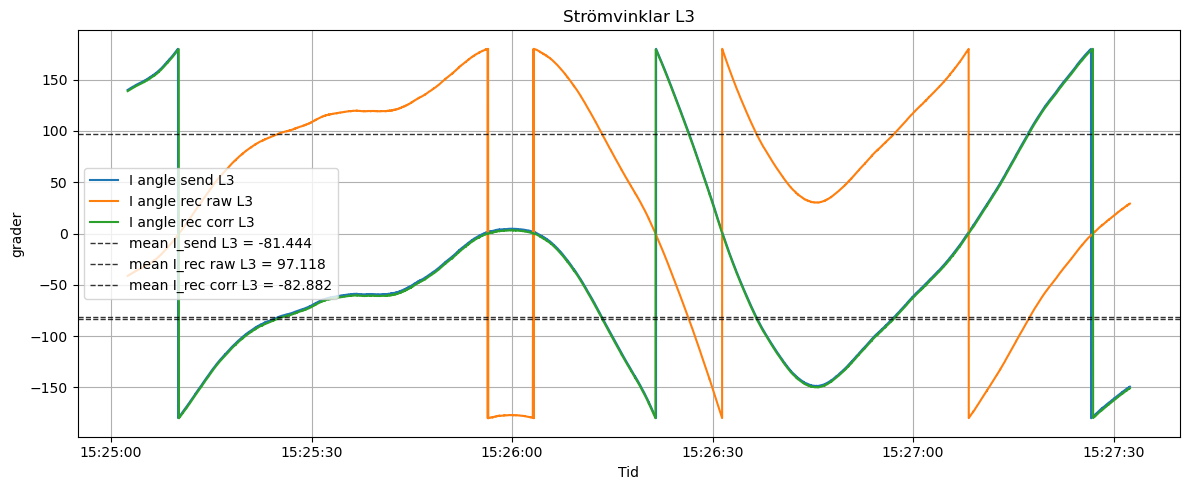

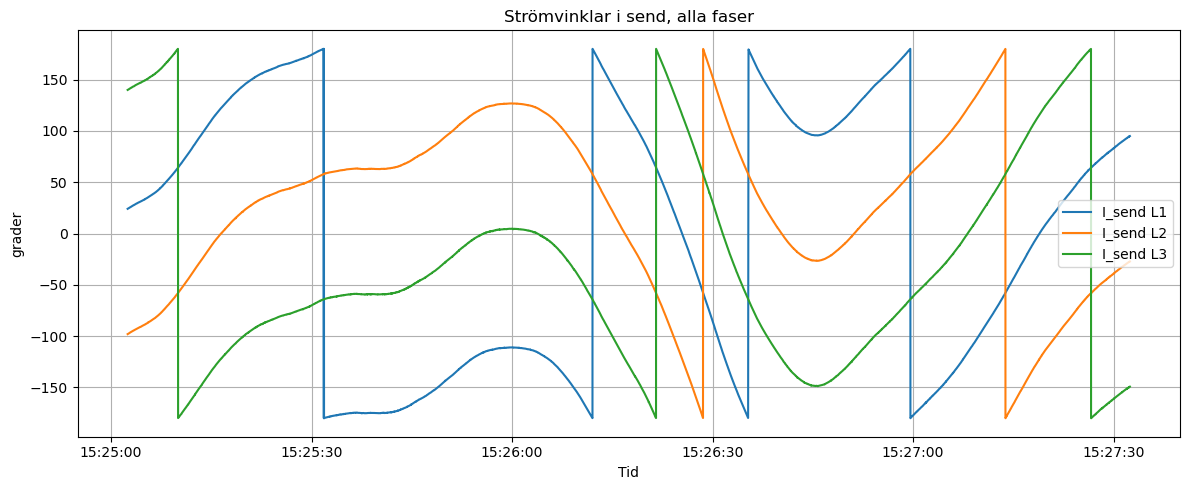

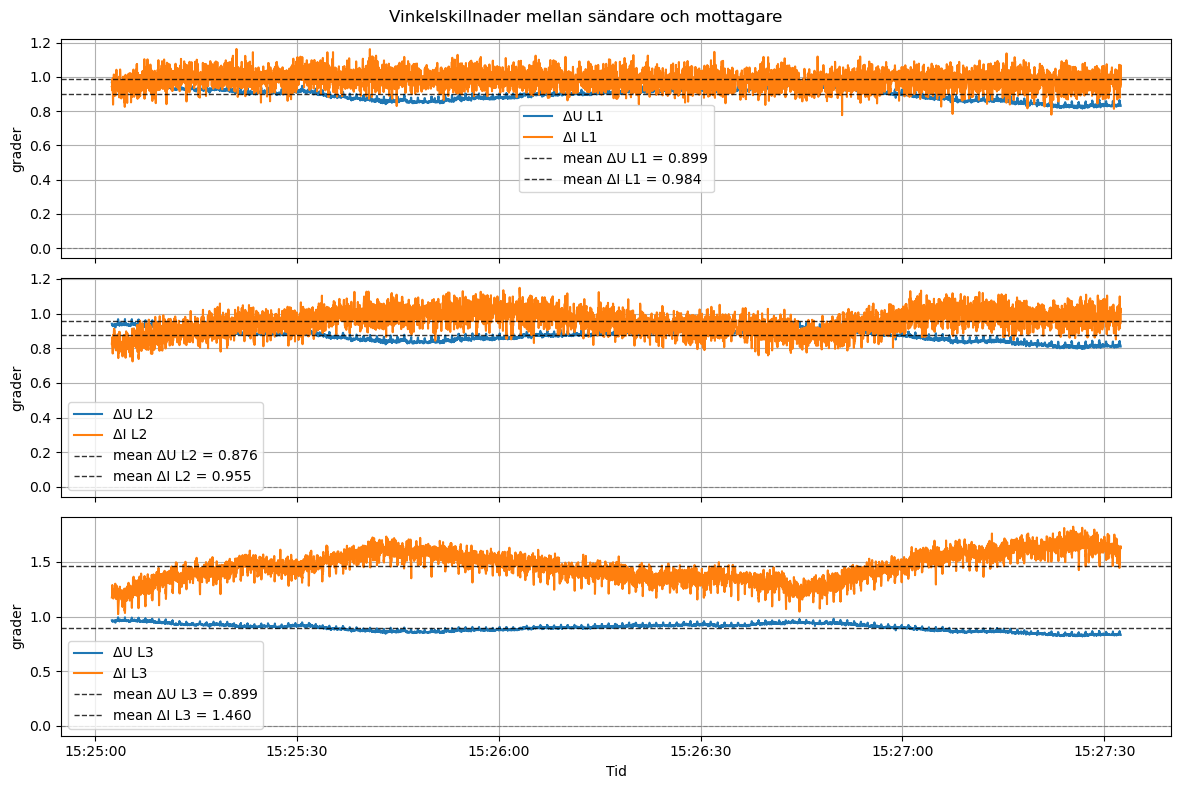

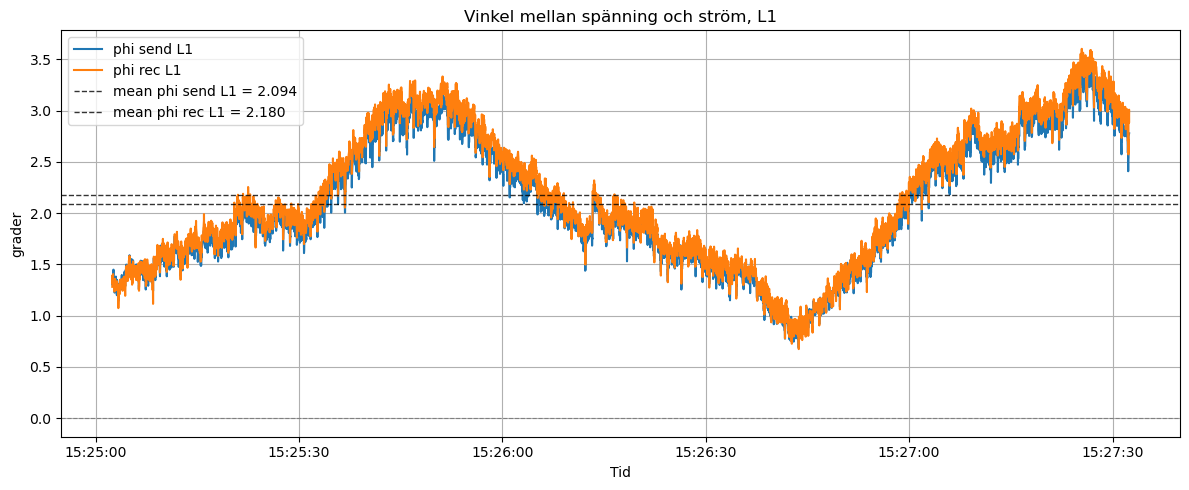

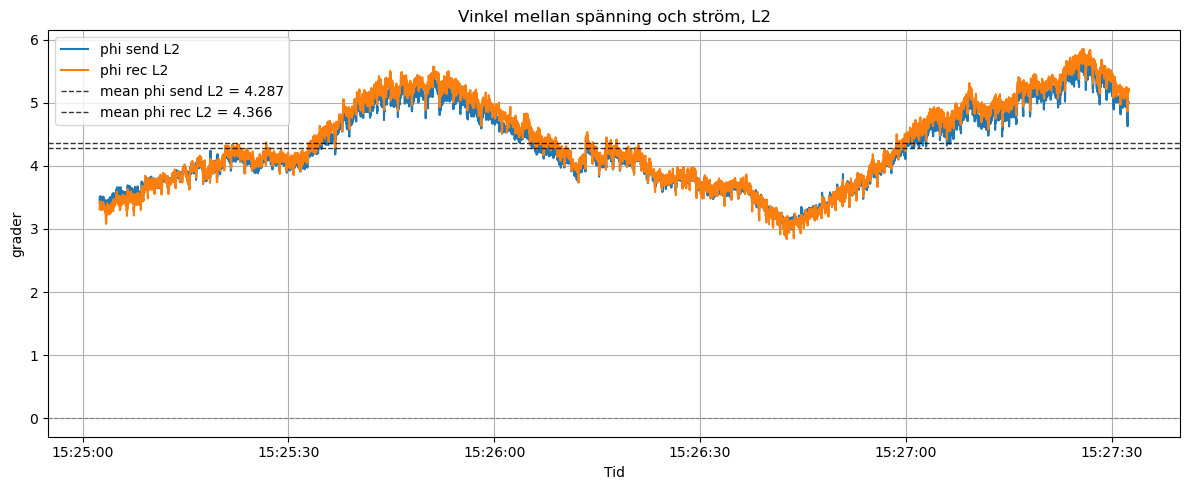

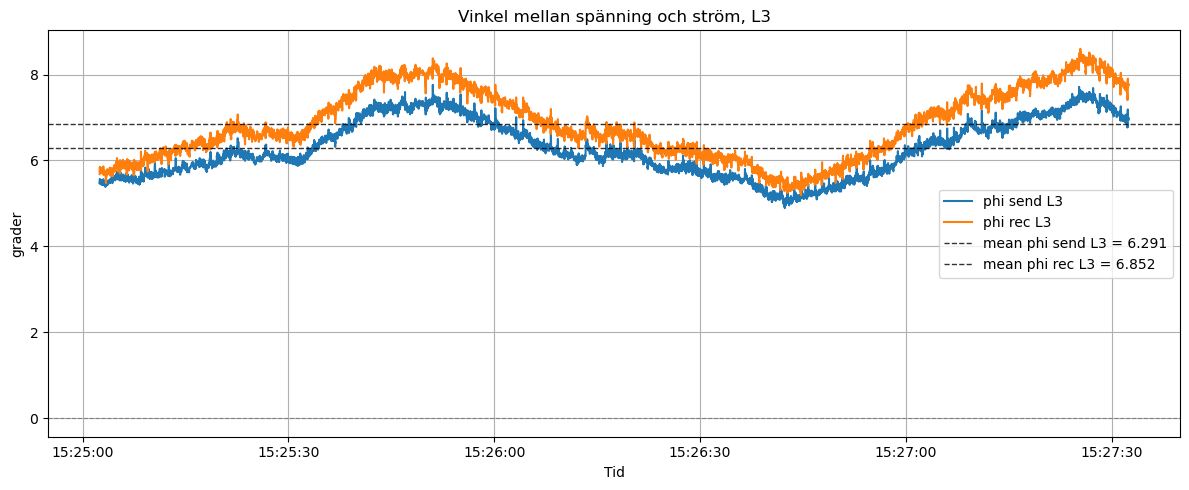

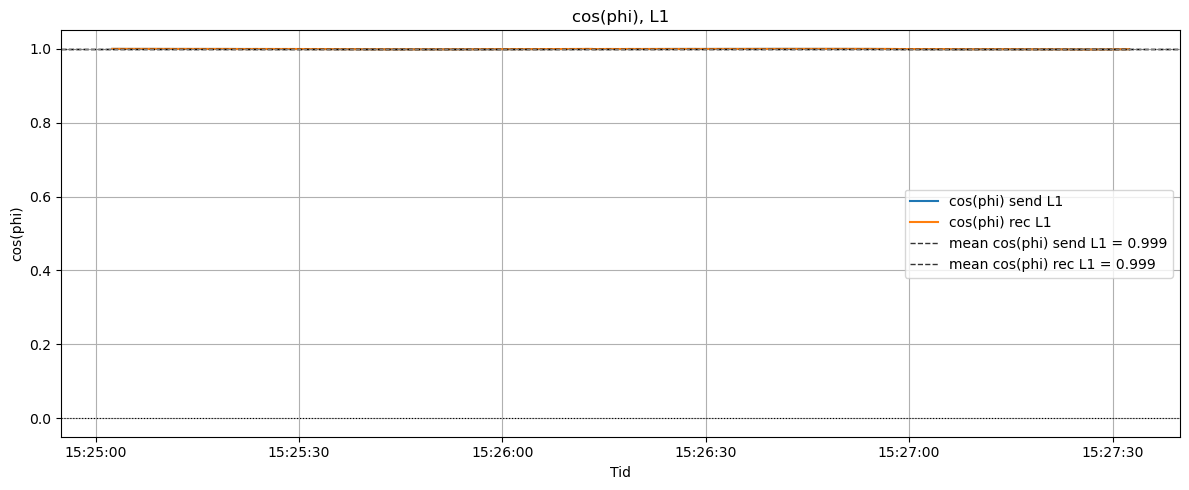

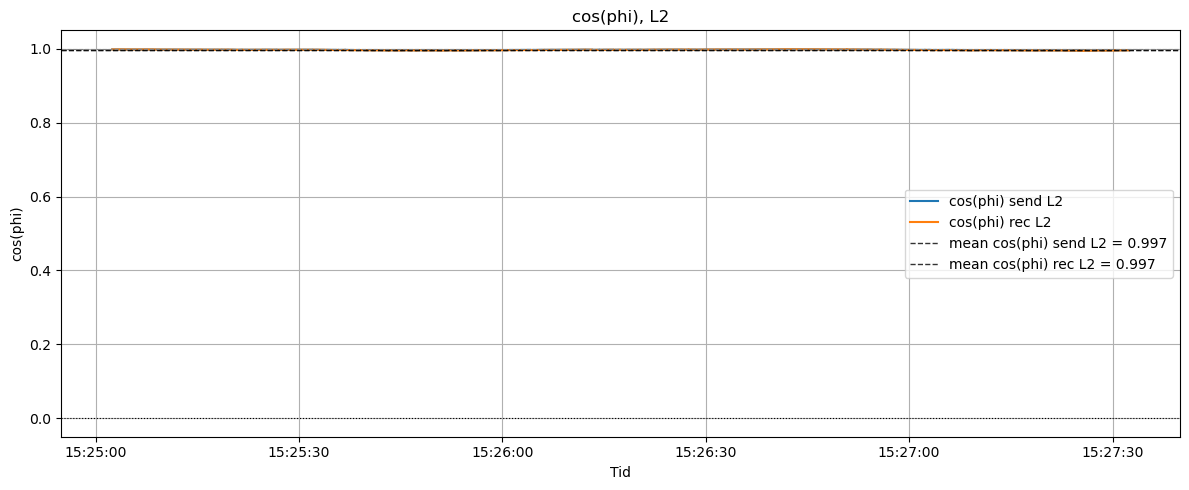

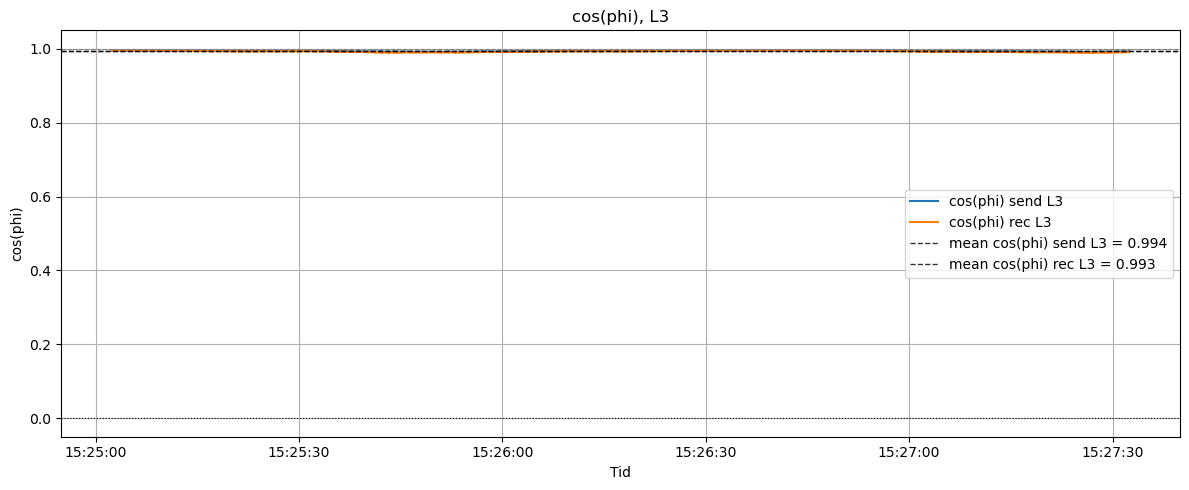

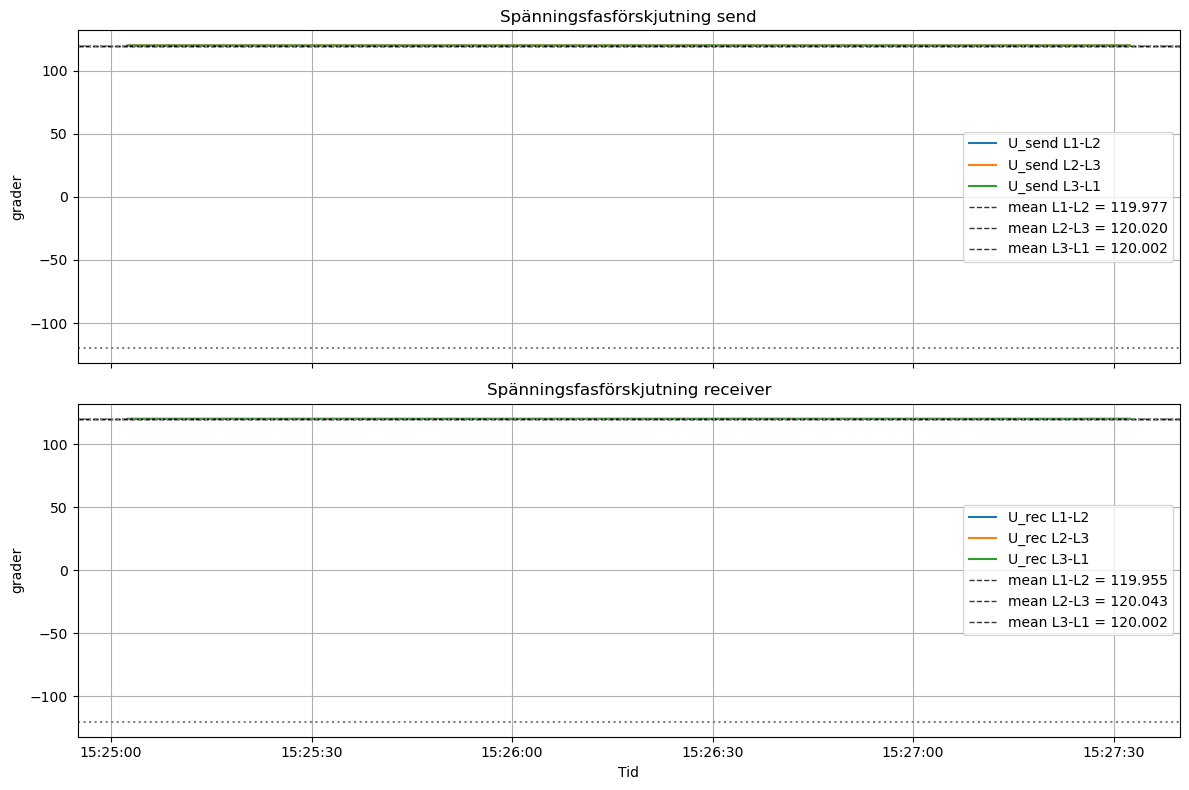

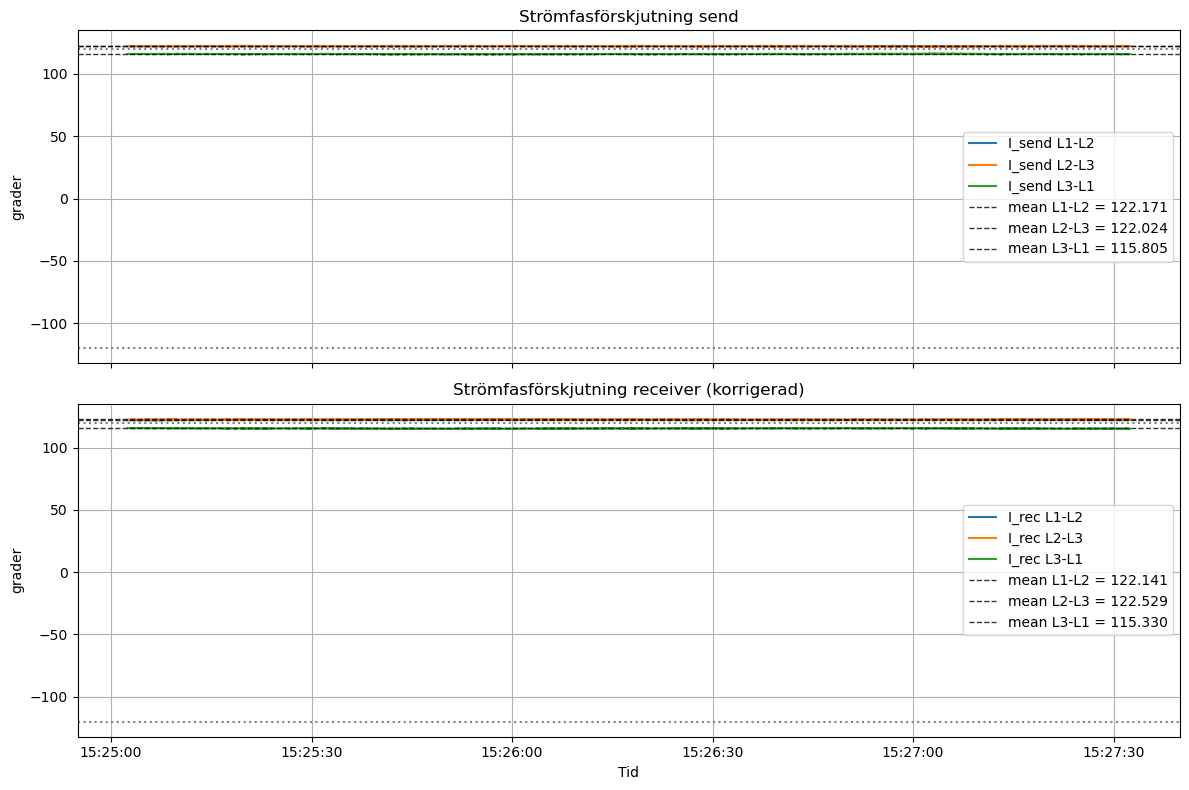

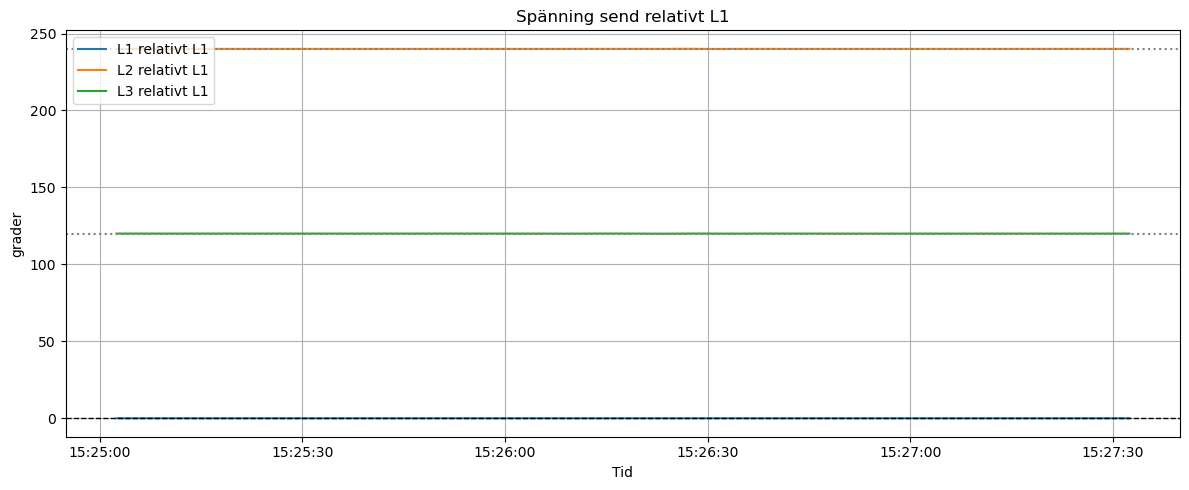

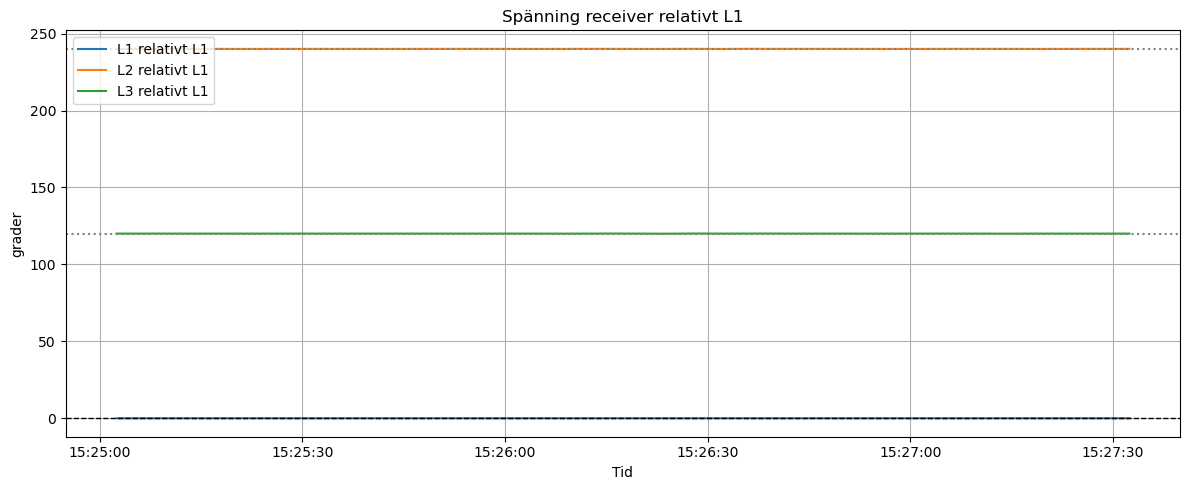

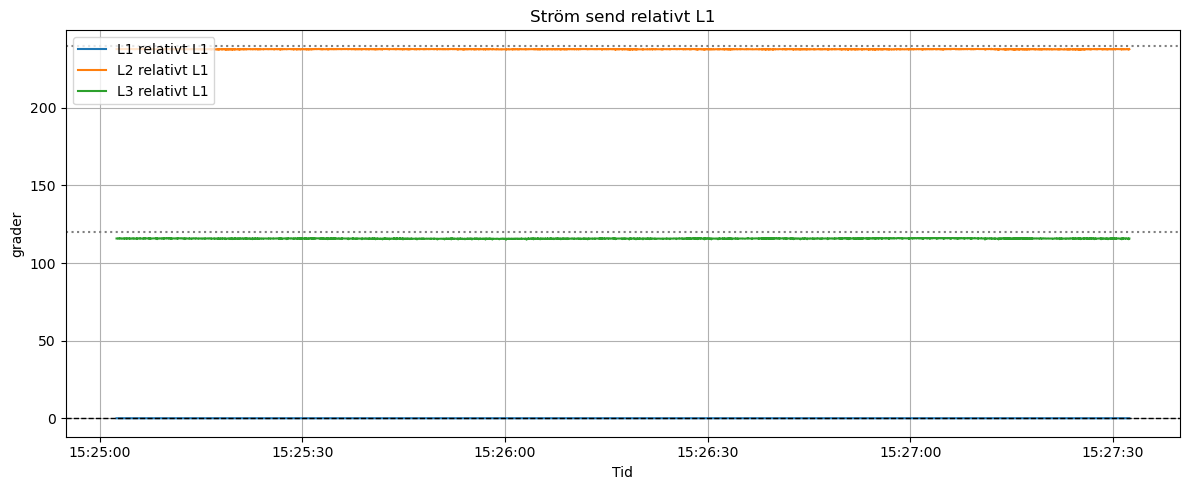

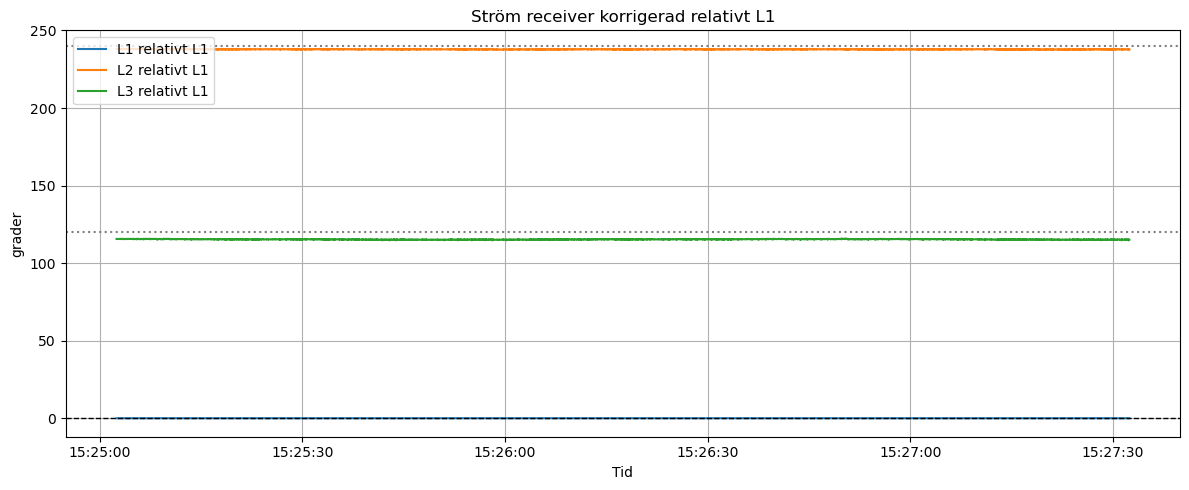

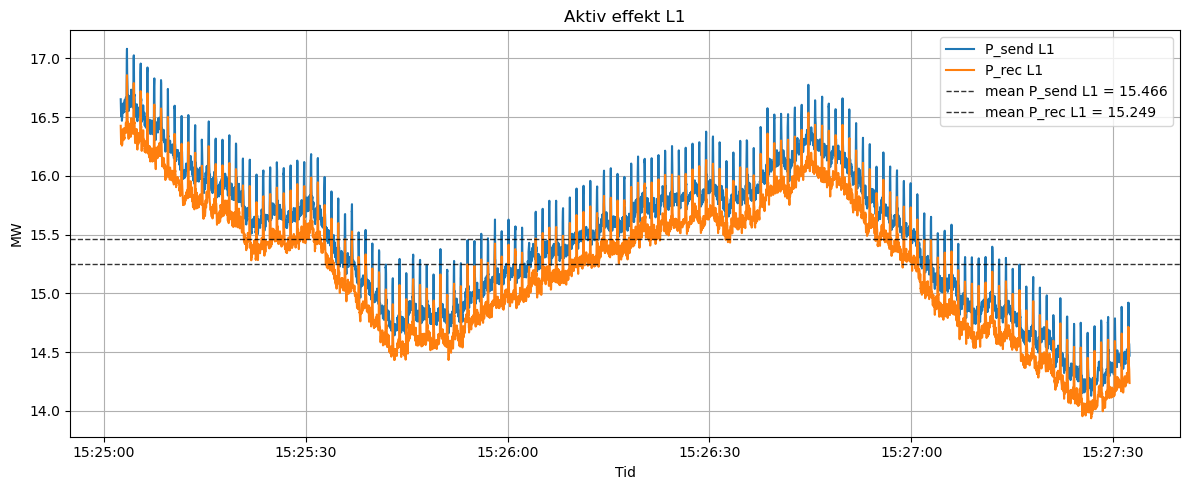

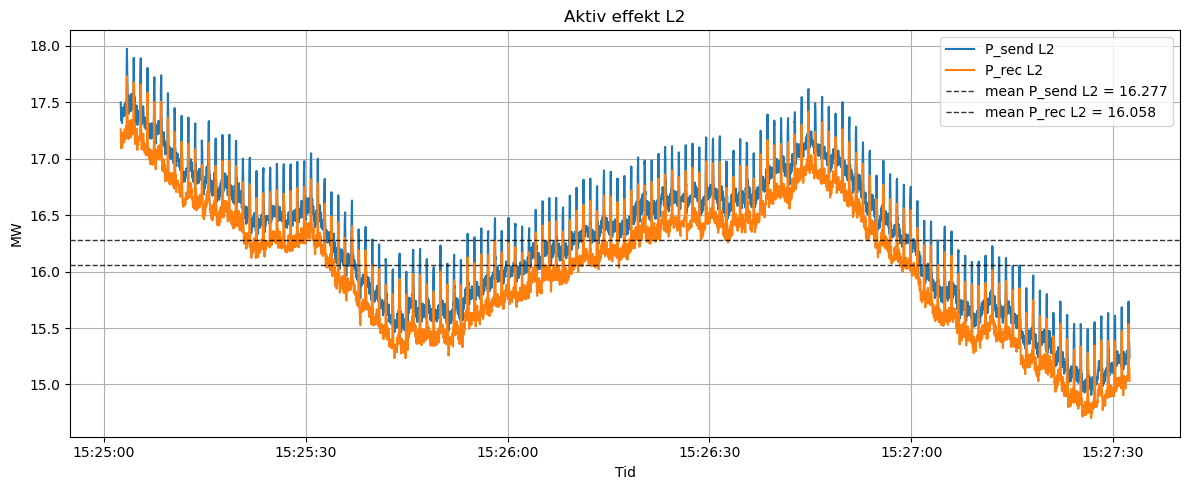

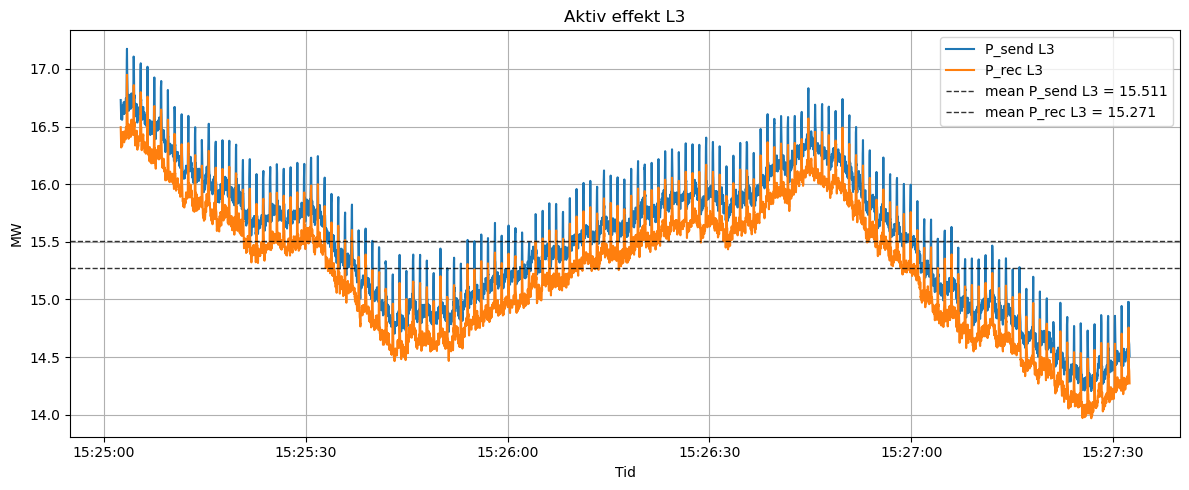

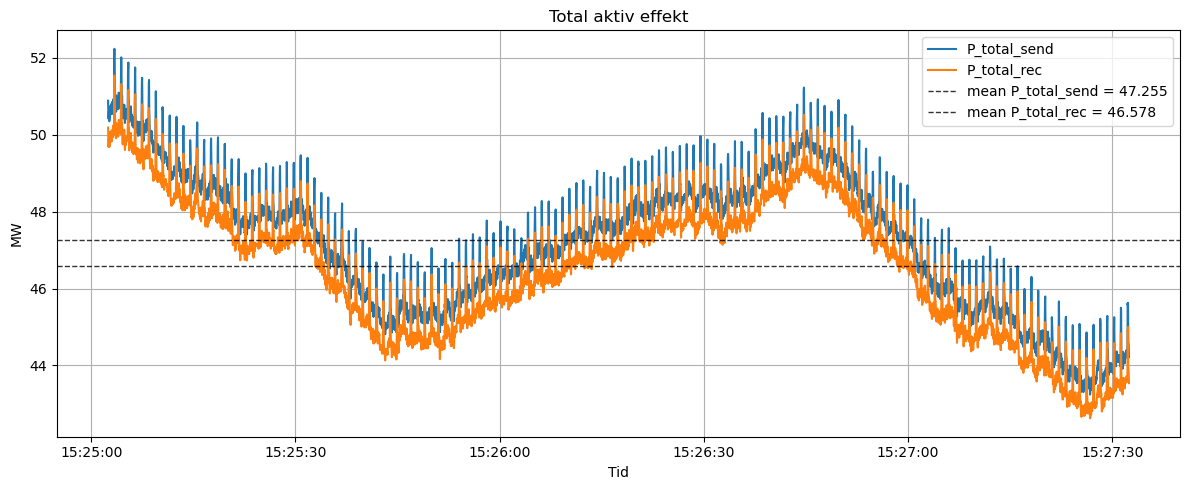

In [6]:
# ============================================================
# FULL ÖVERSIKT AV SEND/REC-DATA
# - läser rådata
# - mappar nyckelblad
# - bygger komplexa storheter
# - inverterar mottagarströmmen
# - plottar strömmar, spänningar, vinklar, effekt
# - visar fasförskjutning mellan L1, L2, L3
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# VERSIONSNAMN FÖR SPARAD OUTPUT
# ============================================================

VERSION = "overview_all_signals_with_phase_reference"

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def to_360(angle_deg):
    return angle_deg % 360.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def add_mean_line(ax, y, label_prefix="mean", circular=False, color="black"):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

# ============================================================
# 1. LÄS OCH MAPPA DATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = read_data_table_safe(send_file, dataS_sheet)
rec  = read_data_table_safe(rec_file, dataR_sheet)

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S").sort_index()
wideR = wideR.add_suffix("_R").sort_index()

df_joined = wideS.join(wideR, how="inner").copy()

required_cols = []
for ph in ["L1", "L2", "L3"]:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_joined.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

df_joined = df_joined.dropna(subset=required_cols).copy()

# filtrera bort orimliga vinkelvärden
angle_cols = [c for c in df_joined.columns if "ANG" in c]
for c in angle_cols:
    df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

print("Antal synkade tidssteg:", len(df_joined))
print("Start:", df_joined.index.min())
print("Slut :", df_joined.index.max())

# ============================================================
# 2. BYGG TABELL MED STRÖM/SPÄNNING/VINKLAR/EFFEKT
# ============================================================

out = pd.DataFrame(index=df_joined.index)

for ph in ["L1", "L2", "L3"]:
    # råa magnituder och vinklar
    out[f"U_mag_S_{ph}"] = df_joined[f"U{ph}MAG_S"]
    out[f"U_mag_R_{ph}"] = df_joined[f"U{ph}MAG_R"]
    out[f"I_mag_S_{ph}"] = df_joined[f"I{ph}MAG_S"]
    out[f"I_mag_R_{ph}"] = df_joined[f"I{ph}MAG_R"]

    out[f"U_ang_S_{ph}"] = df_joined[f"U{ph}ANG_S"]
    out[f"U_ang_R_{ph}"] = df_joined[f"U{ph}ANG_R"]
    out[f"I_ang_S_{ph}"] = df_joined[f"I{ph}ANG_S"]
    out[f"I_ang_R_raw_{ph}"] = df_joined[f"I{ph}ANG_R"]

    # korrigera mottagarström med 180°
    out[f"I_ang_R_corr_{ph}"] = wrap_angle_deg(df_joined[f"I{ph}ANG_R"] + 180.0)

    # komplexa storheter
    Vs = complex_from_mag_ang(out[f"U_mag_S_{ph}"], out[f"U_ang_S_{ph}"])
    Vr = complex_from_mag_ang(out[f"U_mag_R_{ph}"], out[f"U_ang_R_{ph}"])

    Is = complex_from_mag_ang(out[f"I_mag_S_{ph}"], out[f"I_ang_S_{ph}"])
    Ir_corr = complex_from_mag_ang(out[f"I_mag_R_{ph}"], out[f"I_ang_R_corr_{ph}"])

    # aktiv effekt
    out[f"P_send_{ph}"] = np.real(Vs * np.conj(Is))
    out[f"P_rec_{ph}"]  = np.real(Vr * np.conj(Ir_corr))

    # vinkelskillnader mellan stationerna
    out[f"dU_{ph}"] = wrap_angle_deg(out[f"U_ang_S_{ph}"] - out[f"U_ang_R_{ph}"])
    out[f"dI_{ph}"] = wrap_angle_deg(out[f"I_ang_S_{ph}"] - out[f"I_ang_R_corr_{ph}"])

    # vinkel mellan spänning och ström i samma station
    out[f"phi_send_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_S_{ph}"] - out[f"I_ang_S_{ph}"])
    out[f"phi_rec_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_R_{ph}"] - out[f"I_ang_R_corr_{ph}"])

    # cos(phi)
    out[f"cosphi_send_{ph}"] = np.cos(np.deg2rad(out[f"phi_send_deg_{ph}"]))
    out[f"cosphi_rec_{ph}"]  = np.cos(np.deg2rad(out[f"phi_rec_deg_{ph}"]))

# totals
out["P_total_send"] = out[[f"P_send_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)
out["P_total_rec"]  = out[[f"P_rec_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)

# ============================================================
# 3. FASFÖRSKJUTNING MELLAN L1, L2, L3
# ============================================================

# Spänning send
out["dU_send_L1_L2"] = wrap_angle_deg(out["U_ang_S_L1"] - out["U_ang_S_L2"])
out["dU_send_L2_L3"] = wrap_angle_deg(out["U_ang_S_L2"] - out["U_ang_S_L3"])
out["dU_send_L3_L1"] = wrap_angle_deg(out["U_ang_S_L3"] - out["U_ang_S_L1"])

# Spänning receiver
out["dU_rec_L1_L2"] = wrap_angle_deg(out["U_ang_R_L1"] - out["U_ang_R_L2"])
out["dU_rec_L2_L3"] = wrap_angle_deg(out["U_ang_R_L2"] - out["U_ang_R_L3"])
out["dU_rec_L3_L1"] = wrap_angle_deg(out["U_ang_R_L3"] - out["U_ang_R_L1"])

# Ström send
out["dI_send_L1_L2"] = wrap_angle_deg(out["I_ang_S_L1"] - out["I_ang_S_L2"])
out["dI_send_L2_L3"] = wrap_angle_deg(out["I_ang_S_L2"] - out["I_ang_S_L3"])
out["dI_send_L3_L1"] = wrap_angle_deg(out["I_ang_S_L3"] - out["I_ang_S_L1"])

# Ström receiver korrigerad
out["dI_rec_L1_L2"] = wrap_angle_deg(out["I_ang_R_corr_L1"] - out["I_ang_R_corr_L2"])
out["dI_rec_L2_L3"] = wrap_angle_deg(out["I_ang_R_corr_L2"] - out["I_ang_R_corr_L3"])
out["dI_rec_L3_L1"] = wrap_angle_deg(out["I_ang_R_corr_L3"] - out["I_ang_R_corr_L1"])

# Relativt L1 i [0,360)
for prefix in ["U_ang_S", "U_ang_R", "I_ang_S", "I_ang_R_corr"]:
    L1 = out[f"{prefix}_L1"]
    L2 = out[f"{prefix}_L2"]
    L3 = out[f"{prefix}_L3"]

    out[f"{prefix}_L1_rel_360"] = to_360(wrap_angle_deg(L1 - L1))
    out[f"{prefix}_L2_rel_360"] = to_360(wrap_angle_deg(L2 - L1))
    out[f"{prefix}_L3_rel_360"] = to_360(wrap_angle_deg(L3 - L1))

# ============================================================
# 4. SAMMANFATTNINGSTABELLER
# ============================================================

summary_rows = []
for ph in ["L1", "L2", "L3"]:
    summary_rows.append({
        "Phase": ph,
        "U_send_mean": np.nanmean(out[f"U_mag_S_{ph}"]),
        "U_rec_mean": np.nanmean(out[f"U_mag_R_{ph}"]),
        "I_send_mean": np.nanmean(out[f"I_mag_S_{ph}"]),
        "I_rec_mean": np.nanmean(out[f"I_mag_R_{ph}"]),
        "U_ang_send_mean_deg": circular_mean_deg(out[f"U_ang_S_{ph}"]),
        "U_ang_rec_mean_deg": circular_mean_deg(out[f"U_ang_R_{ph}"]),
        "I_ang_send_mean_deg": circular_mean_deg(out[f"I_ang_S_{ph}"]),
        "I_ang_rec_raw_mean_deg": circular_mean_deg(out[f"I_ang_R_raw_{ph}"]),
        "I_ang_rec_corr_mean_deg": circular_mean_deg(out[f"I_ang_R_corr_{ph}"]),
        "dU_mean_deg": circular_mean_deg(out[f"dU_{ph}"]),
        "dI_mean_deg": circular_mean_deg(out[f"dI_{ph}"]),
        "phi_send_mean_deg": circular_mean_deg(out[f"phi_send_deg_{ph}"]),
        "phi_rec_mean_deg": circular_mean_deg(out[f"phi_rec_deg_{ph}"]),
        "cosphi_send_mean": np.nanmean(out[f"cosphi_send_{ph}"]),
        "cosphi_rec_mean": np.nanmean(out[f"cosphi_rec_{ph}"]),
        "P_send_mean_W": np.nanmean(out[f"P_send_{ph}"]),
        "P_rec_mean_W": np.nanmean(out[f"P_rec_{ph}"]),
    })

summary_df = pd.DataFrame(summary_rows)

phase_shift_summary = pd.DataFrame([
    {
        "Signal": "U_send",
        "L1-L2 mean deg": circular_mean_deg(out["dU_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_send_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L3_rel_360"])),
    },
    {
        "Signal": "U_rec",
        "L1-L2 mean deg": circular_mean_deg(out["dU_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_rec_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_L3_rel_360"])),
    },
    {
        "Signal": "I_send",
        "L1-L2 mean deg": circular_mean_deg(out["dI_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_send_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L3_rel_360"])),
    },
    {
        "Signal": "I_rec_corr",
        "L1-L2 mean deg": circular_mean_deg(out["dI_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_rec_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_corr_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_corr_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_corr_L3_rel_360"])),
    },
])

print("\nSAMMANFATTNING:")
display(summary_df)

print("\nFASFÖRSKJUTNING MELLAN L1, L2, L3:")
display(phase_shift_summary)

# ============================================================
# 5. SPARA RESULTAT
# ============================================================

output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

out.reset_index().to_excel(output_dir / "overview_raw_quantities.xlsx", index=False)
summary_df.to_excel(output_dir / "overview_summary.xlsx", index=False)
phase_shift_summary.to_excel(output_dir / "phase_shift_summary.xlsx", index=False)

print("Sparat till:", output_dir)

# ============================================================
# 6. PLOTTA STRÖMMAGNITUDER
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_mag_S_{ph}"], label=f"I_send {ph}")
    ax.plot(out.index, out[f"I_mag_R_{ph}"], label=f"I_rec {ph}")
    add_mean_line(ax, out[f"I_mag_S_{ph}"], label_prefix=f"mean I_send {ph}")
    add_mean_line(ax, out[f"I_mag_R_{ph}"], label_prefix=f"mean I_rec {ph}")
    ax.set_title(f"Strömmagnituder {ph}")
    ax.set_ylabel("A")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_current_{ph}.png", dpi=200)
    plt.show()

# Samlad figur - strömmar send
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"I_mag_S_{ph}"], label=f"I_send {ph}")
ax.set_title("Strömmagnituder i send, alla faser")
ax.set_ylabel("A")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_current_send_all.png", dpi=200)
plt.show()

# ============================================================
# 7. PLOTTA SPÄNNINGSMAGNITUDER
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_mag_S_{ph}"], label=f"U_send {ph}")
    ax.plot(out.index, out[f"U_mag_R_{ph}"], label=f"U_rec {ph}")
    add_mean_line(ax, out[f"U_mag_S_{ph}"], label_prefix=f"mean U_send {ph}")
    add_mean_line(ax, out[f"U_mag_R_{ph}"], label_prefix=f"mean U_rec {ph}")
    ax.set_title(f"Spänningsmagnituder {ph}")
    ax.set_ylabel("V")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_voltage_{ph}.png", dpi=200)
    plt.show()

# Samlad figur - spänningar send
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"U_mag_S_{ph}"], label=f"U_send {ph}")
ax.set_title("Spänningsmagnituder i send, alla faser")
ax.set_ylabel("V")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_voltage_send_all.png", dpi=200)
plt.show()

# ============================================================
# 8. PLOTTA SPÄNNINGSVINKLAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_ang_S_{ph}"], label=f"U angle send {ph}")
    ax.plot(out.index, out[f"U_ang_R_{ph}"], label=f"U angle rec {ph}")
    add_mean_line(ax, out[f"U_ang_S_{ph}"], label_prefix=f"mean U_send {ph}", circular=True)
    add_mean_line(ax, out[f"U_ang_R_{ph}"], label_prefix=f"mean U_rec {ph}", circular=True)
    ax.set_title(f"Spänningsvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_U_angles_{ph}.png", dpi=200)
    plt.show()

# Samlad figur - spänningsvinklar send
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"U_ang_S_{ph}"], label=f"U_send {ph}")
ax.set_title("Spänningsvinklar i send, alla faser")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_U_angles_send_all.png", dpi=200)
plt.show()

# ============================================================
# 9. PLOTTA STRÖMVINKLAR (RAW + CORR)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_ang_S_{ph}"], label=f"I angle send {ph}")
    ax.plot(out.index, out[f"I_ang_R_raw_{ph}"], label=f"I angle rec raw {ph}")
    ax.plot(out.index, out[f"I_ang_R_corr_{ph}"], label=f"I angle rec corr {ph}")
    add_mean_line(ax, out[f"I_ang_S_{ph}"], label_prefix=f"mean I_send {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_raw_{ph}"], label_prefix=f"mean I_rec raw {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_corr_{ph}"], label_prefix=f"mean I_rec corr {ph}", circular=True)
    ax.set_title(f"Strömvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_I_angles_{ph}.png", dpi=200)
    plt.show()

# Samlad figur - strömvinklar send
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"I_ang_S_{ph}"], label=f"I_send {ph}")
ax.set_title("Strömvinklar i send, alla faser")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_I_angles_send_all.png", dpi=200)
plt.show()

# ============================================================
# 10. PLOTTA VINKELSKILLNADER MELLAN STATIONER
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, out[f"dU_{ph}"], label=f"ΔU {ph}")
    axs[i].plot(out.index, out[f"dI_{ph}"], label=f"ΔI {ph}")
    add_mean_line(axs[i], out[f"dU_{ph}"], label_prefix=f"mean ΔU {ph}", circular=True)
    add_mean_line(axs[i], out[f"dI_{ph}"], label_prefix=f"mean ΔI {ph}", circular=True)
    axs[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("grader")
axs[-1].set_xlabel("Tid")
fig.suptitle("Vinkelskillnader mellan sändare och mottagare")
fig.tight_layout()
fig.savefig(output_dir / "plot_angle_differences.png", dpi=200)
plt.show()

# ============================================================
# 11. PLOTTA VINKEL MELLAN U OCH I (phi) OCH cos(phi)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"phi_send_deg_{ph}"], label=f"phi send {ph}")
    ax.plot(out.index, out[f"phi_rec_deg_{ph}"], label=f"phi rec {ph}")
    add_mean_line(ax, out[f"phi_send_deg_{ph}"], label_prefix=f"mean phi send {ph}", circular=True)
    add_mean_line(ax, out[f"phi_rec_deg_{ph}"], label_prefix=f"mean phi rec {ph}", circular=True)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Vinkel mellan spänning och ström, {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_phi_{ph}.png", dpi=200)
    plt.show()

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"cosphi_send_{ph}"], label=f"cos(phi) send {ph}")
    ax.plot(out.index, out[f"cosphi_rec_{ph}"], label=f"cos(phi) rec {ph}")
    add_mean_line(ax, out[f"cosphi_send_{ph}"], label_prefix=f"mean cos(phi) send {ph}")
    add_mean_line(ax, out[f"cosphi_rec_{ph}"], label_prefix=f"mean cos(phi) rec {ph}")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8)
    ax.set_title(f"cos(phi), {ph}")
    ax.set_ylabel("cos(phi)")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_cosphi_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 12. PLOTTA FASFÖRSKJUTNING MELLAN L1, L2, L3
# ============================================================

# Spänningsfaser send/receiver
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(out.index, out["dU_send_L1_L2"], label="U_send L1-L2")
axs[0].plot(out.index, out["dU_send_L2_L3"], label="U_send L2-L3")
axs[0].plot(out.index, out["dU_send_L3_L1"], label="U_send L3-L1")
add_mean_line(axs[0], out["dU_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dU_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dU_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Spänningsfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(out.index, out["dU_rec_L1_L2"], label="U_rec L1-L2")
axs[1].plot(out.index, out["dU_rec_L2_L3"], label="U_rec L2-L3")
axs[1].plot(out.index, out["dU_rec_L3_L1"], label="U_rec L3-L1")
add_mean_line(axs[1], out["dU_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dU_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dU_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Spänningsfasförskjutning receiver")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / "plot_phase_shift_voltage.png", dpi=200)
plt.show()

# Strömfaser send/receiver
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(out.index, out["dI_send_L1_L2"], label="I_send L1-L2")
axs[0].plot(out.index, out["dI_send_L2_L3"], label="I_send L2-L3")
axs[0].plot(out.index, out["dI_send_L3_L1"], label="I_send L3-L1")
add_mean_line(axs[0], out["dI_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dI_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dI_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Strömfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(out.index, out["dI_rec_L1_L2"], label="I_rec L1-L2")
axs[1].plot(out.index, out["dI_rec_L2_L3"], label="I_rec L2-L3")
axs[1].plot(out.index, out["dI_rec_L3_L1"], label="I_rec L3-L1")
add_mean_line(axs[1], out["dI_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dI_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dI_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Strömfasförskjutning receiver (korrigerad)")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / "plot_phase_shift_current.png", dpi=200)
plt.show()

# Relativt L1 i [0,360)
for prefix, title in [
    ("U_ang_S", "Spänning send relativt L1"),
    ("U_ang_R", "Spänning receiver relativt L1"),
    ("I_ang_S", "Ström send relativt L1"),
    ("I_ang_R_corr", "Ström receiver korrigerad relativt L1"),
]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(out.index, out[f"{prefix}_L1_rel_360"], label="L1 relativt L1")
    ax.plot(out.index, out[f"{prefix}_L2_rel_360"], label="L2 relativt L1")
    ax.plot(out.index, out[f"{prefix}_L3_rel_360"], label="L3 relativt L1")
    ax.axhline(0, color="black", linestyle="--", linewidth=1.0)
    ax.axhline(120, color="gray", linestyle=":")
    ax.axhline(240, color="gray", linestyle=":")
    ax.set_title(title)
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_relative_to_L1_{prefix}.png", dpi=200)
    plt.show()

# ============================================================
# 13. PLOTTA AKTIV EFFEKT PER FAS OCH TOTAL
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"P_send_{ph}"] / 1e6, label=f"P_send {ph}")
    ax.plot(out.index, out[f"P_rec_{ph}"] / 1e6, label=f"P_rec {ph}")
    add_mean_line(ax, out[f"P_send_{ph}"] / 1e6, label_prefix=f"mean P_send {ph}")
    add_mean_line(ax, out[f"P_rec_{ph}"] / 1e6, label_prefix=f"mean P_rec {ph}")
    ax.set_title(f"Aktiv effekt {ph}")
    ax.set_ylabel("MW")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_power_{ph}.png", dpi=200)
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(out.index, out["P_total_send"] / 1e6, label="P_total_send")
ax.plot(out.index, out["P_total_rec"] / 1e6, label="P_total_rec")
add_mean_line(ax, out["P_total_send"] / 1e6, label_prefix="mean P_total_send")
add_mean_line(ax, out["P_total_rec"] / 1e6, label_prefix="mean P_total_rec")
ax.set_title("Total aktiv effekt")
ax.set_ylabel("MW")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_power_total.png", dpi=200)
plt.show()

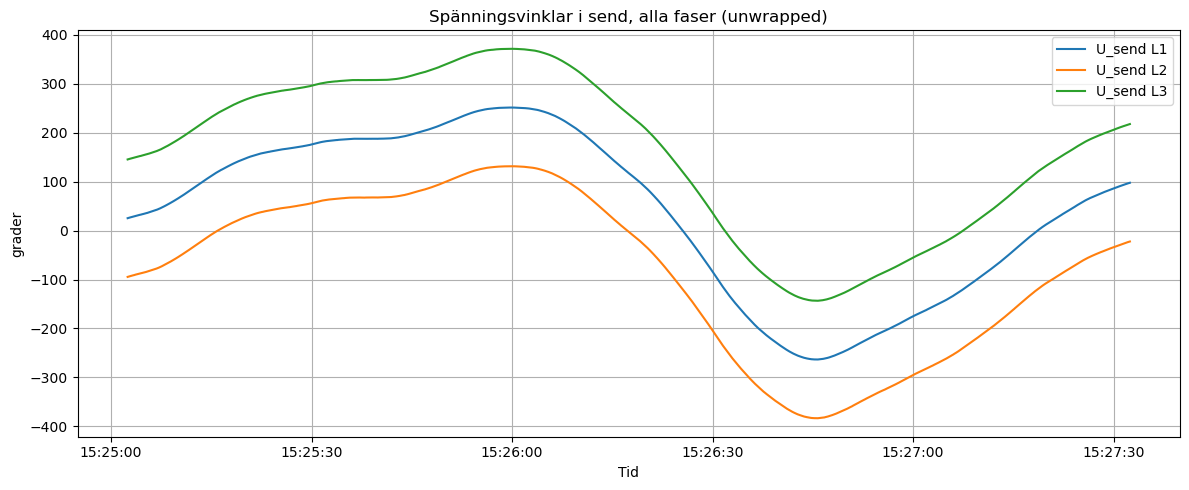

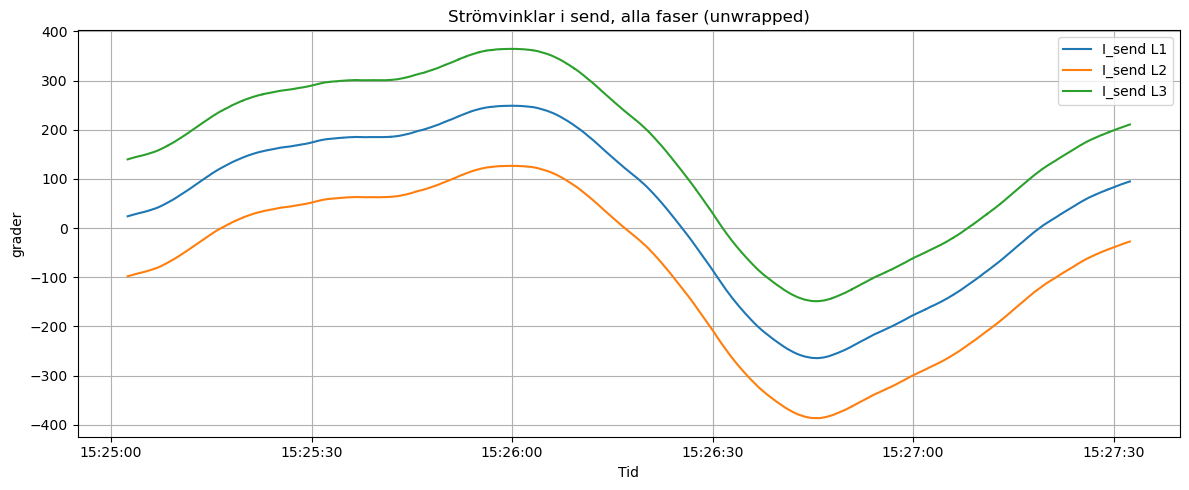

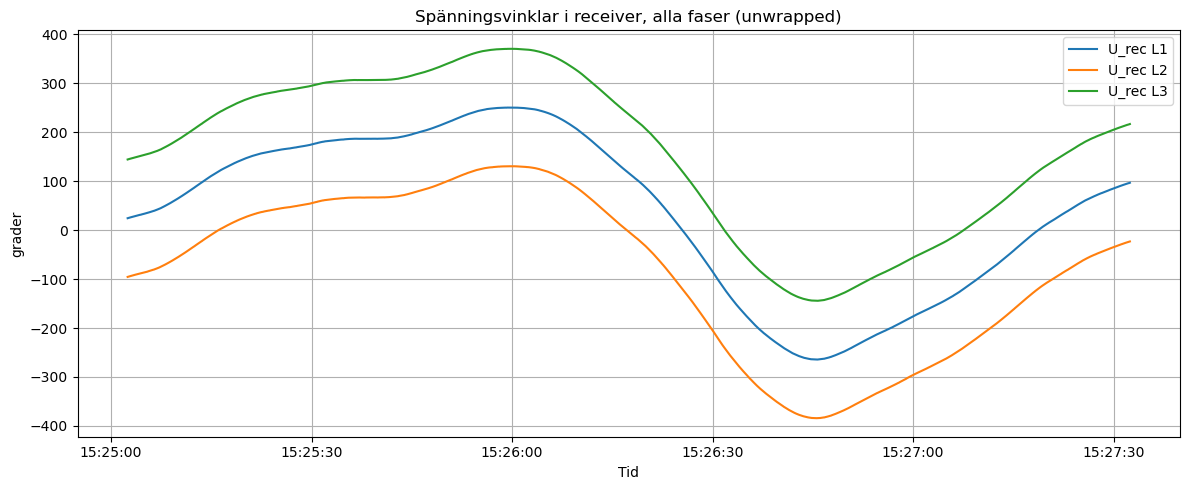

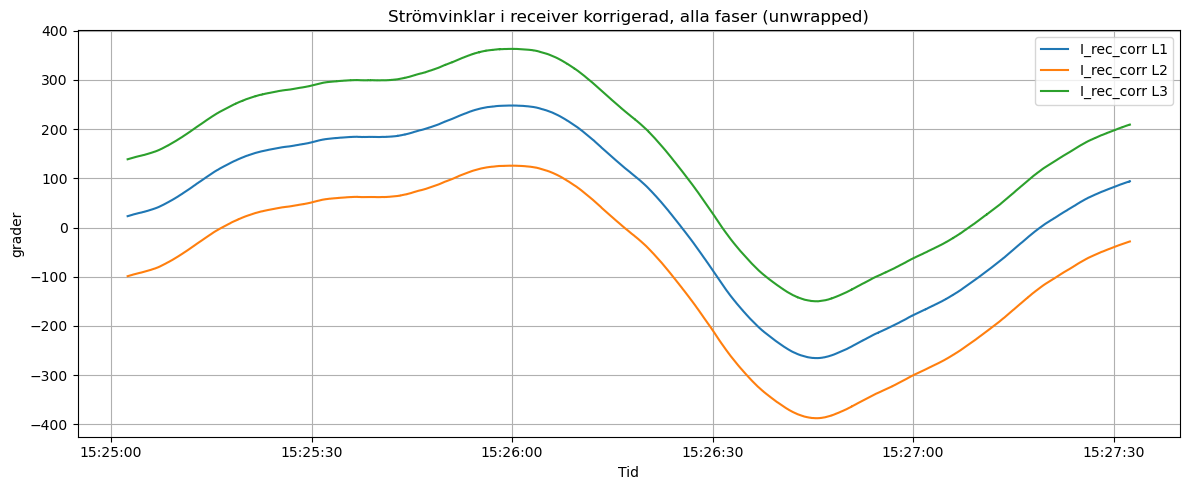

In [7]:
def unwrap_deg(angle_deg_series):
    angle_rad = np.deg2rad(np.asarray(angle_deg_series, dtype=float))
    return np.rad2deg(np.unwrap(angle_rad))

# Spänningsvinklar send, alla faser
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, unwrap_deg(out[f"U_ang_S_{ph}"]), label=f"U_send {ph}")
ax.set_title("Spänningsvinklar i send, alla faser (unwrapped)")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Strömvinklar send, alla faser
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, unwrap_deg(out[f"I_ang_S_{ph}"]), label=f"I_send {ph}")
ax.set_title("Strömvinklar i send, alla faser (unwrapped)")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Spänningsvinklar receiver, alla faser
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, unwrap_deg(out[f"U_ang_R_{ph}"]), label=f"U_rec {ph}")
ax.set_title("Spänningsvinklar i receiver, alla faser (unwrapped)")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Strömvinklar receiver korrigerad, alla faser
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, unwrap_deg(out[f"I_ang_R_corr_{ph}"]), label=f"I_rec_corr {ph}")
ax.set_title("Strömvinklar i receiver korrigerad, alla faser (unwrapped)")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()